<a href="https://colab.research.google.com/github/rafaellopesdesa/nsbi-lhc-toolkit/blob/ml4hep_school_tutorial/workshops/ml4hep_tifr_colab/Exercise_9b_SBIBM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Exercise 9b — CE-corrected hybrid inference versus pure JANA on `sbibm`

This notebook runs the ten `sbibm` tasks as a paired, matched-capacity comparison.  Every fold first learns the same normalized conditional flow ensembles

$$q_\phi(z\mid x),\qquad q_\eta(x\mid z).$$

The **pure-JANA baseline** uses these two flows directly: posterior draws come from $q_\phi$ and posterior-predictive draws compose $q_\phi$ with $q_\eta$.  The **hybrid CE method** uses the very same flow checkpoints and simulation rows, then applies the structured three-class CE correction through $\exp a$ and $\exp c$.  Thus the head-to-head comparison changes the correction and nothing else—not the proposal capacity, ensemble, cross-fit split, observation adapter, or simulator budget.

This is a method-level, matched-capacity implementation of JANA's $\lambda=0$ benchmark objective, not an attempt to load the historical TensorFlow/BayesFlow checkpoints.  With disjoint posterior and likelihood parameters, JANA's summed NLL separates exactly into the two conditional-flow NLLs already optimized here.  The historical checkpoints use older task adapters and network topologies, so mixing their samples into the present `sbibm==1.1.0` campaign would not be an apples-to-apples correction test.

The hybrid classifier retains the fixed CE-family objective

$$
\mathcal L_{\rm train}=\mathcal L_{\rm CE}
  +\lambda_a\left(\mathcal L_{a,\mathrm{direct}}-\log 2\right).
$$

Neither conditional normalization nor the bridge variance enters training or checkpoint selection.  The headline aggregate follows the quantity used in JANA Figure 5: posterior MMD and **$x$-only posterior-predictive MMD**.  MMD on the concatenated $(\theta,x_{\rm rep})$ pair is retained as a stricter supplemental diagnostic.  Both methods are always evaluated with one shared reference sample and one reference-only kernel bandwidth, so a lower MMD is a genuine paired comparison rather than a bandwidth artifact.


In [13]:
# Google Colab setup -- safe to rerun and a no-op outside Colab.
import importlib
import importlib.util
import os, sys, subprocess
from importlib.metadata import PackageNotFoundError, version as package_version
from pathlib import Path

REPO_URL = "https://github.com/rafaellopesdesa/nsbi-lhc-toolkit.git"
BRANCH = "ml4hep_school_tutorial"
USE_DRIVE = os.environ.get("EX9B_USE_DRIVE", "1") != "0"

def run(*args, env=None):
    subprocess.run([str(arg) for arg in args], check=True, env=env)

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    if USE_DRIVE:
        from google.colab import drive
        drive.mount("/content/drive")
        SOURCE_ROOT = Path("/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab")
        default_artifact_root = Path(
            "/content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM"
        )
    else:
        SOURCE_ROOT = Path("/content")
        default_artifact_root = Path("/content/exercise_9b_SBIBM_artifacts")
    SOURCE_ROOT.mkdir(parents=True, exist_ok=True)
    REPO_DIR = SOURCE_ROOT / "nsbi-lhc-toolkit"
    TUTORIAL_DIR = REPO_DIR / "workshops" / "ml4hep_tifr_colab"
    if not (REPO_DIR / ".git").is_dir():
        clone_env = os.environ.copy()
        clone_env["GIT_LFS_SKIP_SMUDGE"] = "1"
        run(
            "git", "clone", "--depth", "1", "--filter=blob:none", "--sparse",
            "--branch", BRANCH, REPO_URL, REPO_DIR, env=clone_env,
        )
    else:
        run("git", "-C", REPO_DIR, "remote", "set-url", "origin", REPO_URL)
        run("git", "-C", REPO_DIR, "fetch", "origin", BRANCH)
        run("git", "-C", REPO_DIR, "checkout", BRANCH)
        run("git", "-C", REPO_DIR, "pull", "--ff-only", "origin", BRANCH)
    run(
        "git", "-C", REPO_DIR, "sparse-checkout", "set",
        "src", "workshops/ml4hep_tifr_colab",
    )
    for import_dir in (REPO_DIR / "src", TUTORIAL_DIR):
        path = str(import_dir.resolve())
        if path not in sys.path:
            sys.path.insert(0, path)

    def installed_version(distribution):
        try:
            return package_version(distribution)
        except PackageNotFoundError:
            return None

    # Exercise 10 compatibility contract: resolve only the modern runtime
    # dependencies. sbibm 1.1.0's optional historical algorithm stack is
    # unused here and cannot be resolved on Python 3.12+.
    if installed_version("nflows") != "0.14" or importlib.util.find_spec("pyro") is None:
        run(sys.executable, "-m", "pip", "install", "-q", "nflows==0.14", "pyro-ppl")
    if installed_version("sbibm") != "1.1.0":
        run(sys.executable, "-m", "pip", "install", "-q", "--no-deps", "sbibm==1.1.0")

    # SIR and Lotka--Volterra import diffeqtorch even when an exact cached
    # simulation bank is used. Install only the small Python import layer;
    # this does not claim to install Julia or enable fresh ODE simulations.
    if installed_version("julia") != "0.6.2" or importlib.util.find_spec("opt_einsum") is None:
        run(sys.executable, "-m", "pip", "install", "-q", "julia==0.6.2", "opt_einsum")
    if installed_version("diffeqtorch") != "1.0.0":
        run(sys.executable, "-m", "pip", "install", "-q", "--no-deps", "diffeqtorch==1.0.0")
    importlib.invalidate_caches()
    import nflows, pyro, sbibm
    assert installed_version("nflows") == "0.14"
    assert installed_version("sbibm") == "1.1.0"
    print(
        "Pinned runtime: nflows=0.14, sbibm=1.1.0 (--no-deps); "
        "ODE task imports enabled, Julia simulator backend not installed"
    )
    os.chdir(TUTORIAL_DIR)
else:
    default_artifact_root = Path.cwd() / "exercise_9b_SBIBM_artifacts"
    for candidate in [Path.cwd(), Path.cwd() / "workshops" / "ml4hep_tifr_colab"]:
        if (candidate / "utils_hnpe.py").exists():
            sys.path.insert(0, str(candidate.resolve()))
            break

ARTIFACT_ROOT = Path(
    os.environ.get("EX9B_ARTIFACT_ROOT", str(default_artifact_root))
).expanduser().resolve()
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)
os.environ["EX9B_ARTIFACT_ROOT"] = str(ARTIFACT_ROOT)
print("Working directory:", Path.cwd())
print("Persistent Exercise-9b artifact root:", ARTIFACT_ROOT)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Pinned runtime: nflows=0.14, sbibm=1.1.0 (--no-deps); ODE task imports enabled, Julia simulator backend not installed
Working directory: /content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/workshops/ml4hep_tifr_colab
Persistent Exercise-9b artifact root: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM


In [14]:
import copy
import gc
import hashlib
import inspect
import json
import math
import os
import random
import traceback
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sbibm
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display
from scipy.special import logsumexp
from scipy.spatial.distance import cdist, pdist
from torch.utils.data import DataLoader, TensorDataset

from utils_benchmark import (
    infer_parameter_transform,
    load_or_simulate_bank,
    split_simulation_bank,
    task_recommendation_table,
)
from utils_hnpe import (
    sample_spline_flow_ensemble,
    spline_flow_ensemble_log_prob,
    train_spline_flow_ensemble,
)
from utils_plotting import export_standalone_figure_script

DEFAULT_SEED = 29082026
# Reserve a generous offset beyond the largest paired metric/C2ST seed.
MAX_LEGACY_SEED_OFFSET = 100_000 * 9 + 150_000 + 10
MAX_BASE_SEED = 2**32 - 1 - MAX_LEGACY_SEED_OFFSET
SEED = int(os.environ.get("EX9B_SEED", str(DEFAULT_SEED)))
if not 0 <= SEED <= MAX_BASE_SEED:
    raise ValueError(
        f"EX9B_SEED must lie in [0, {MAX_BASE_SEED}] so every derived "
        "legacy NumPy/sklearn seed remains valid."
    )
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def seed_everything(seed):
    random.seed(int(seed))
    np.random.seed(int(seed) % 2**32)
    torch.manual_seed(int(seed))
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(int(seed))

seed_everything(SEED)
print("sbibm version:", sbibm.__version__)
print("Using device:", device)


sbibm version: 1.1.0
Using device: cuda


## 1. A controlled pure-JANA versus hybrid-CE experiment

In latent parameter coordinates $z=T(\theta)$, the learned reference models are normalized conditional flows $q_\phi(z\mid x)$ and $q_\eta(x\mid z)$.  The matched-capacity **pure JANA** route is therefore

$$z\sim q_\phi(z\mid x),\qquad x_{\rm rep}\sim q_\eta(x\mid z).$$

For the benchmark experiments JANA sets the summary-space MMD coefficient to zero.  Its density objective is the sum of posterior and likelihood NLLs.  Because the two flows here have disjoint parameters (and vector observations require no shared summary network), fitting the two NLLs separately is algebraically equivalent to optimizing that sum.  Ensembling, cross-fitting, transforms, and early stopping are held fixed for both routes; this is deliberately a comparison of **direct JANA inference versus CE correction**, not a comparison of software frameworks.

The hybrid route additionally forms the three equal-prior class laws

$$
S=\rho_z(z)p(x\mid z),\qquad
P=m(x)q_\phi(z\mid x),\qquad
L=\rho_z(z)q_\eta(x\mid z),
$$

with two ratio heads

$$a(z,x)=\log(S/P),\qquad c(z,x)=\log(S/L),$$

and structured logits $[a,0,a-c]$.  The $a$ head also receives the balanced $S/P$ binary-CE pre-flight signal.  Both heads use the same enlarged pre-normalized residual architecture (512 hidden features and six residual blocks in FAST/FULL), and classifier members are averaged in log-ratio space.  Every classifier input uses the robust transform $\operatorname{asinh}[(y-\operatorname{median}y)/(1.4826\,\operatorname{MAD}y)]$ with standard deviation only as a zero-MAD fallback.

For a strict paired comparison, each hybrid posterior reweights the same finite $q_\phi$ proposal bank from which the direct-JANA sample is drawn.  The methods also share the same observation jitters, flow members, folds, and official evaluation reference.


## 2. Training, normalization, and bridge checks

The two reference flows are normalized by construction.  Pure JANA uses them without any extra correction.  The hybrid ratios should additionally obey

$$Z_P(x)=\mathbb E_{q_\phi(z\mid x)}e^{a(z,x)}=1,\qquad
  Z_L(z)=\mathbb E_{q_\eta(x\mid z)}e^{c(z,x)}=1.$$

These identities are **not losses**.  After the CE checkpoint is fixed, independent Monte Carlo banks anchored on a disjoint audit subset provide two estimates of each $Z$.  We report the cross estimate $(Z_A-1)(Z_B-1)$ and a pooled positive square for plotting.  Neither statistic can affect gradients, early stopping, or model selection.

The raw pure-JANA evidence path is

$$
\log m_{\rm JANA}(x;z)=
\log\rho_z(z)+\log q_\eta(x\mid z)-\log q_\phi(z\mid x),
$$

whereas the hybrid path adds $c-a$.  Both should be independent of $z$ at fixed $x$.  We therefore compare the held-out variances of the direct-JANA and corrected evidence paths on exactly the same IID audit bank.  This is a consistency check, not a training target and never a prediction weight.

At inference time the hybrid $a$ and $c$ weights are self-normalized on their finite proposal banks.  Direct JANA draws directly from the normalized flows.  Every metric row records which inference route was used.


In [15]:
ALL_TASKS = (
    "gaussian_linear", "gaussian_linear_uniform", "gaussian_mixture",
    "two_moons", "slcp", "slcp_distractors", "bernoulli_glm",
    "bernoulli_glm_raw", "sir", "lotka_volterra",
)
PROFILE = "FULL"
TASK_NAME = os.environ.get("EX9B_TASK", "two_moons")
RUN_ALL_TASKS = True
LOAD_IF_AVAILABLE = False
FAIL_ON_TASK_ERROR = False

METHOD_JANA = "jana_direct"
METHOD_HYBRID = "hybrid_ce"
METHODS = (METHOD_JANA, METHOD_HYBRID)
METHOD_LABELS = {
    METHOD_JANA: "Pure JANA (direct flows)",
    METHOD_HYBRID: "Hybrid + CE correction",
}
METRIC_SCHEMA = "paired_long_reference_bandwidth_v1"
JANA_PAPER_COMMIT = "6cbbc94faf0aa85147986f7f9516d13a52551bd4"

PROFILES = {
    "SMOKE": dict(
        num_simulations=1_000, n_folds=2, flow_members=1,
        flow_epochs=2, class_epochs=3, class_width=128, class_blocks=2,
        norm_groups=32, norm_inner=4, bridge_groups=24, bridge_inner=4,
        n_proposal=1_500, n_posterior=1_000,
        observations=[1], observation_jitters=4,
        predictive_candidates=4, predictive_samples=256,
        predictive_reference_calls=256,
    ),
    "FAST": dict(
        num_simulations=10_000, n_folds=2, flow_members=2,
        flow_epochs=25, class_epochs=40, class_width=512, class_blocks=6,
        norm_groups=256, norm_inner=16, bridge_groups=128, bridge_inner=12,
        n_proposal=30_000, n_posterior=5_000,
        observations=[1, 2, 3], observation_jitters=8,
        predictive_candidates=8, predictive_samples=1_000,
        predictive_reference_calls=1_000,
    ),
    "FULL": dict(
        num_simulations=100_000, n_folds=5, flow_members=4,
        flow_epochs=90, class_epochs=120, class_width=512, class_blocks=6,
        norm_groups=1_024, norm_inner=64, bridge_groups=512, bridge_inner=32,
        n_proposal=150_000, n_posterior=10_000,
        observations=list(range(1, 11)), observation_jitters=32,
        predictive_candidates=16, predictive_samples=2_000,
        predictive_reference_calls=2_000,
    ),
}
if PROFILE not in PROFILES:
    raise ValueError(f"PROFILE must be one of {tuple(PROFILES)}")
if TASK_NAME not in ALL_TASKS:
    raise ValueError(f"TASK_NAME must be one of {ALL_TASKS}")
campaign = PROFILES[PROFILE]
TASKS_TO_RUN = ALL_TASKS if RUN_ALL_TASKS else (TASK_NAME,)

LAMBDA_DIRECT = 1.0
LOG_RATIO_BOUND = 18.0
CAMPAIGN_SCHEMA = "structured_v9_paired_jana_hybrid_ce_post_training_checks"
CAMPAIGN_SIGNATURE = "sha256-" + hashlib.sha256(json.dumps({
    "campaign_schema": CAMPAIGN_SCHEMA,
    "metric_schema": METRIC_SCHEMA,
    "profile": PROFILE, "campaign": campaign,
    "methods": METHODS,
    "jana_baseline": "matched_crossfit_qphi_qeta_direct_no_classifier_v1",
    "jana_paper_commit": JANA_PAPER_COMMIT,
    "lambda_direct": LAMBDA_DIRECT,
    "log_ratio_bound": LOG_RATIO_BOUND,
    "flow_topology": "equal_weight_lu_rqs_ensemble_v1",
    "classifier_transform": "robust_median_mad_asinh_v1",
    "classifier_objective": "multiclass_ce_plus_direct_a_binary_ce_v1",
    "checkpoint_objective": "held_out_ce_family_only_v1",
    "diagnostic_split": "disjoint_post_training_audit_rows_v1",
    "normalization_role": "post_training_self_normalization_and_held_out_check_v1",
    "bridge_role": "paired_jana_and_hybrid_held_out_evidence_check_v1",
    "data_semantics": "bernoulli_sir_dequant_lv_lognormal_continuous_v1",
    "posterior_predictive": "paired_jana_direct_and_hybrid_finite_k_sir_v1",
    "mmd_bandwidth": "shared_reference_only_median_rbf_v1",
}, sort_keys=True).encode("utf-8")).hexdigest()[:12]

def campaign_run_tag(seed):
    return (
        f"v9_{PROFILE.lower()}_seed{int(seed)}_n{campaign['num_simulations']}_"
        f"k{campaign['n_folds']}_flowmix{campaign['flow_members']}_"
        f"cfg{CAMPAIGN_SIGNATURE}_paired_jana_hybrid_ce"
    )

RUN_TAG = campaign_run_tag(SEED)
aggregate_seed_text = os.environ.get("EX9B_AGGREGATE_SEEDS", "").strip()
if aggregate_seed_text:
    try:
        AGGREGATE_SEEDS = tuple(dict.fromkeys(
            int(value.strip()) for value in aggregate_seed_text.split(",")
            if value.strip()
        ))
    except ValueError as exc:
        raise ValueError("EX9B_AGGREGATE_SEEDS must be comma-separated integers.") from exc
else:
    AGGREGATE_SEEDS = (SEED,)
if not AGGREGATE_SEEDS or any(not 0 <= value <= MAX_BASE_SEED for value in AGGREGATE_SEEDS):
    raise ValueError(
        f"Every aggregate seed must lie in [0, {MAX_BASE_SEED}] so its "
        "derived legacy NumPy/sklearn seeds remain valid."
    )
AGGREGATE_RUN_TAGS = tuple(campaign_run_tag(seed) for seed in AGGREGATE_SEEDS)
AGGREGATE_TAG = (
    RUN_TAG if AGGREGATE_SEEDS == (SEED,) else
    f"v9_{PROFILE.lower()}_seeds{'-'.join(map(str, AGGREGATE_SEEDS))}_"
    f"cfg{CAMPAIGN_SIGNATURE}_aggregate"
)

ARTIFACT_ROOT = Path(os.environ["EX9B_ARTIFACT_ROOT"]).expanduser().resolve()
MODEL_ROOT = ARTIFACT_ROOT / "models"
CACHE_ROOT = ARTIFACT_ROOT / "simulation_banks"
RESULT_ROOT = ARTIFACT_ROOT / "results"
FIGURE_ROOT = ARTIFACT_ROOT / "figures_scripts"
for directory in (MODEL_ROOT, CACHE_ROOT, RESULT_ROOT, FIGURE_ROOT):
    directory.mkdir(parents=True, exist_ok=True)

recommendations = task_recommendation_table().copy()
lv_row = recommendations["task"] == "lotka_volterra"
recommendations.loc[lv_row, "data_type"] = "continuous LogNormal-noised trajectories"
recommendations.loc[lv_row, "reason"] = (
    "The official simulator returns continuous LogNormal-noised trajectories; "
    "no dequantization is applied."
)
display(recommendations.style.hide(axis="index"))
print(json.dumps({
    "profile": PROFILE, "seed": SEED,
    "tasks_this_run": TASKS_TO_RUN, "run_tag": RUN_TAG,
    "campaign_signature": CAMPAIGN_SIGNATURE,
    "metric_schema": METRIC_SCHEMA,
    "methods": METHOD_LABELS,
    "jana_baseline": "direct q_phi/q_eta from the same cross-fit flow checkpoints",
    "jana_paper_commit": JANA_PAPER_COMMIT,
    "artifact_root": str(ARTIFACT_ROOT),
    "model_root": str(MODEL_ROOT),
    "simulation_bank_root": str(CACHE_ROOT),
    "result_root": str(RESULT_ROOT),
    "figure_root": str(FIGURE_ROOT),
    "aggregate_seeds": AGGREGATE_SEEDS,
    "aggregate_run_tags": AGGREGATE_RUN_TAGS,
    "hybrid_loss": "multiclass CE + direct-a binary CE (normalization/bridge excluded)",
    "checkpoint_selection": "held-out CE-family objective only",
    "normalization": "post-training hybrid self-normalization plus held-out diagnostic",
    "bridge": "paired pure-JANA and hybrid held-out consistency diagnostic only",
    "mmd_bandwidth": "one reference-only bandwidth shared by both methods",
    "flow_mixture_members": campaign["flow_members"],
    "classifier_members": campaign["flow_members"],
    "crossfit_folds": campaign["n_folds"],
    "predictive_candidates_per_theta": campaign["predictive_candidates"],
    "predictive_samples": campaign["predictive_samples"],
    "evaluation_simulator_calls_per_observation": campaign["predictive_reference_calls"],
}, indent=2))


task,display_name,dim_parameters,dim_data,data_type,recommended_method,colab_status,reason
gaussian_linear,Gaussian Linear,10,10,continuous,dual hNPE--hNDE,ready,A normalization and scaling control; the posterior is nearly solved.
gaussian_linear_uniform,Gaussian Linear Uniform,10,10,"continuous, bounded parameters",dual hNPE--hNDE,ready,Tests exact bounded support through the parameter logit transform.
gaussian_mixture,Gaussian Mixture,2,2,continuous mixture,dual hNPE--hNDE,ready,A compact heavy-tail test; corrected v1.1 benchmark results are used.
two_moons,Two Moons,2,2,"continuous, multimodal",dual hNPE--hNDE,primary target,The paper's diagnostic example has curved modes and clear headroom.
slcp,SLCP,5,8,"continuous, four-mode posterior",dual hNPE--hNDE,stretch target,The best published mean C2ST at 100k is still far from 0.5.
slcp_distractors,SLCP Distractors,5,100,continuous with 92 distractors,hNPE; optional dual,expensive,hNPE avoids making a 100-dimensional observation flow the bottleneck.
bernoulli_glm,Bernoulli GLM,10,10,discrete-derived sufficient statistics,hNPE,ready,A conditional posterior can use the summaries directly; a continuous hNDE reference is not an exact probability-mass model.
bernoulli_glm_raw,Bernoulli GLM Raw,10,100,binary,hNPE,expensive,The raw observation is discrete and 100-dimensional.
sir,SIR,2,10,count time series,hNPE,Julia backend required,The official simulator uses diffeqtorch/Julia; hNDE would need a discrete or dequantized reference model.
lotka_volterra,Lotka--Volterra,4,20,continuous LogNormal-noised trajectories,hNPE,Julia backend required,The official simulator returns continuous LogNormal-noised trajectories; no dequantization is applied.


{
  "profile": "FULL",
  "seed": 29082026,
  "tasks_this_run": [
    "gaussian_linear",
    "gaussian_linear_uniform",
    "gaussian_mixture",
    "two_moons",
    "slcp",
    "slcp_distractors",
    "bernoulli_glm",
    "bernoulli_glm_raw",
    "sir",
    "lotka_volterra"
  ],
  "run_tag": "v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_hybrid_ce",
  "campaign_signature": "sha256-3fd6d89c19ad",
  "metric_schema": "paired_long_reference_bandwidth_v1",
  "methods": {
    "jana_direct": "Pure JANA (direct flows)",
    "hybrid_ce": "Hybrid + CE correction"
  },
  "jana_baseline": "direct q_phi/q_eta from the same cross-fit flow checkpoints",
  "jana_paper_commit": "6cbbc94faf0aa85147986f7f9516d13a52551bd4",
  "artifact_root": "/content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM",
  "model_root": "/content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/models",
  "simulation_bank_root": "/content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/simulation_ban

## 3. Discrete observations: an explicit change of measure

`bernoulli_glm_raw` and SIR live on an integer lattice.  We use randomized dequantization $\widetilde x=x+u$ with $u_j\sim\mathrm{Uniform}[-w_j/2,w_j/2]$ and train a **continuous density of $\widetilde x$**.  For raw binary/count data $w_j=1$, so integrating a perfect dequantized density over the unit cell recovers a probability mass.  At an observed integer vector, posterior evaluation averages over multiple cell jitters rather than pretending the cell center is a continuous observation.

`bernoulli_glm` is a derived sufficient statistic on an irregular finite support.  Its data-driven rectangular jitter is only a declared smoothing convention; it is **not** an exact PMF representation.  Accordingly, density/evidence values from that task must not be labeled exact likelihoods.  C2ST and MMD against the official posterior remain meaningful tests of the resulting inference procedure.

Official `sbibm` Lotka--Volterra observations are continuous LogNormal-noised trajectories.  They therefore receive zero dequantization width and no observation jitter in training, posterior evaluation, or predictive evaluation.  The bootstrap installs `sbibm==1.1.0` with `--no-deps`, following Exercise 10, plus only the lightweight Python import layer for `diffeqtorch`; it does **not** install or emulate Julia.  The official SIR and Lotka--Volterra simulators still require their Julia backend.  An exact cached prior-predictive bank avoids repeating the **training** simulations, but it does not replace fresh simulator calls required for posterior-predictive evaluation.  This notebook neither silently drops those stages nor substitutes a different simulator.  A failure writes a JSON manifest and, by default, raises after displaying it.


In [16]:
DISCRETE_TASKS = {"bernoulli_glm", "bernoulli_glm_raw", "sir"}

def require_finite_rows(task_name, stage, values):
    if torch.is_tensor(values):
        values = values.detach().cpu().numpy()
    array = np.asarray(values)
    if array.ndim == 0:
        array = array.reshape(1, 1)
    elif array.ndim == 1:
        array = array.reshape(-1, 1)
    flat = array.reshape(len(array), -1)
    finite_rows = np.isfinite(flat).all(axis=1)
    if not finite_rows.all():
        bad = int((~finite_rows).sum())
        raise FloatingPointError(
            f"{task_name} [{stage}]: {bad}/{len(flat)} rows contain non-finite values"
        )
    return array

def dequantization_widths(task_name, values):
    values = np.asarray(values, dtype=np.float32)
    if task_name not in DISCRETE_TASKS:
        return np.zeros(values.shape[1], dtype=np.float32)
    if task_name != "bernoulli_glm":
        return np.ones(values.shape[1], dtype=np.float32)
    # The sufficient-statistic support is irregular.  This deterministic
    # local scale defines smoothing only; it does not claim PMF semantics.
    widths = []
    for column in values.T:
        unique = np.unique(np.round(column[: min(len(column), 20_000)], 7))
        gaps = np.diff(unique)
        gaps = gaps[gaps > 1.0e-7]
        robust_scale = np.std(column, dtype=np.float64)
        width = np.median(gaps) if len(gaps) else 0.02 * robust_scale
        width = np.clip(width, 1.0e-4, max(1.0e-4, 0.10 * robust_scale))
        widths.append(width)
    return np.asarray(widths, dtype=np.float32)

def dequantize(values, widths, seed):
    values = np.asarray(values, dtype=np.float32)
    widths = np.asarray(widths, dtype=np.float32)
    if not np.any(widths):
        return values.copy()
    rng = np.random.default_rng(int(seed))
    return (values + (rng.random(values.shape) - 0.5) * widths).astype(np.float32)

def install_inverse_rqs_float64_retry():
    """Retry the same finite inverse-RQS tensors in float64 on cancellation."""
    import functools
    import importlib
    module = importlib.import_module("nflows.transforms.splines.rational_quadratic")
    original = module.rational_quadratic_spline
    if getattr(original, "_ex9b_float64_retry", False):
        return original
    signature = inspect.signature(original)

    @functools.wraps(original)
    def guarded(*args, **kwargs):
        try:
            return original(*args, **kwargs)
        except AssertionError as error32:
            bound = signature.bind(*args, **kwargs)
            inputs = bound.arguments["inputs"]
            inverse = bound.arguments.get("inverse", False)
            if not inverse or inputs.dtype != torch.float32:
                raise
            floating = [v for v in (*args, *kwargs.values()) if torch.is_tensor(v) and v.is_floating_point()]
            if any(not bool(torch.isfinite(v).all()) for v in floating):
                raise FloatingPointError("Non-finite tensor reached inverse RQS") from error32
            convert = lambda v: v.double() if torch.is_tensor(v) and v.is_floating_point() else v
            try:
                output, logdet = original(
                    *(convert(v) for v in args),
                    **{k: convert(v) for k, v in kwargs.items()},
                )
            except AssertionError as error64:
                raise RuntimeError("Inverse RQS discriminant also failed in float64") from error64
            if not bool(torch.isfinite(output).all() and torch.isfinite(logdet).all()):
                raise FloatingPointError("Float64 inverse RQS returned non-finite values")
            guarded.retry_count += 1
            if guarded.retry_count == 1:
                warnings.warn("Inverse-RQS cancellation: retrying identical tensors in float64.", RuntimeWarning)
            return output.to(inputs.dtype), logdet.to(inputs.dtype)

    guarded._ex9b_float64_retry = True
    guarded.retry_count = 0
    module.rational_quadratic_spline = guarded
    importlib.import_module("nflows.transforms.splines").rational_quadratic_spline = guarded
    importlib.import_module("nflows.transforms.autoregressive").rational_quadratic_spline = guarded
    return guarded

RQS_GUARD = install_inverse_rqs_float64_retry()


In [17]:
class PreNormResidualBlock(nn.Module):
    def __init__(self, width):
        super().__init__()
        self.norm = nn.LayerNorm(int(width))
        self.linear_one = nn.Linear(int(width), int(width))
        self.linear_two = nn.Linear(int(width), int(width))

    def forward(self, values):
        update = self.linear_one(self.norm(values))
        update = self.linear_two(F.silu(update))
        return values + update / math.sqrt(2.0)

class RatioHead(nn.Module):
    def __init__(self, input_dim, width, blocks):
        super().__init__()
        self.input_layer = nn.Linear(int(input_dim), int(width))
        self.blocks = nn.ModuleList([PreNormResidualBlock(width) for _ in range(int(blocks))])
        self.final_norm = nn.LayerNorm(int(width))
        self.output_layer = nn.Linear(int(width), 1)
        nn.init.zeros_(self.output_layer.weight)
        nn.init.zeros_(self.output_layer.bias)

    def forward(self, values):
        hidden = F.silu(self.input_layer(values))
        for block in self.blocks:
            hidden = block(hidden)
        return self.output_layer(F.silu(self.final_norm(hidden)))[:, 0]

class StructuredThreeClass(nn.Module):
    def __init__(self, input_dim, width, blocks, log_ratio_bound=18.0):
        super().__init__()
        self.a_head = RatioHead(input_dim, width, blocks)
        self.c_head = RatioHead(input_dim, width, blocks)
        self.log_ratio_bound = float(log_ratio_bound)

    def heads(self, values):
        bound = self.log_ratio_bound
        a = self.a_head(values)
        c = self.c_head(values)
        if bound > 0:
            a = bound * torch.tanh(a / bound)
            c = bound * torch.tanh(c / bound)
        return a, c

    def forward(self, values):
        a, c = self.heads(values)
        return torch.stack([a, torch.zeros_like(a), a - c], dim=1)

def model_parameter_counts(model):
    return {
        "a_head": sum(p.numel() for p in model.a_head.parameters()),
        "c_head": sum(p.numel() for p in model.c_head.parameters()),
        "total": sum(p.numel() for p in model.parameters()),
    }

preview_model = StructuredThreeClass(
    12, campaign["class_width"], campaign["class_blocks"], LOG_RATIO_BOUND
)
print("Structured classifier parameter counts:", model_parameter_counts(preview_model))
del preview_model


Structured classifier parameter counts: {'a_head': 3166209, 'c_head': 3166209, 'total': 6332418}


In [18]:
def flow_model_config(n_target):
    # The 100-dimensional distractor/raw tasks need a memory-aware version
    # of the same LU-mixed topology; this is recorded in every checkpoint.
    high_dimensional = int(n_target) > 20
    return {
        "n_unbounded_affine_layers": 2,
        "affine_hidden_features": 256 if high_dimensional else 512,
        "affine_hidden_layers": 3,
        "use_layer_permutations": False,
        "n_coupling_layers": 8 if high_dimensional else 10,
        "hidden_features": 384 if high_dimensional else 512,
        "hidden_layers": 4,
        "spline_num_bins": 16 if high_dimensional else 32,
        "spline_tail_bound": 15.0,
        "dropout_probability": 0.0,
        "activation": "silu",
        "identity_initialization": True,
        "linear_mixing": "lu",
        "standardize_target": True,
    }

FLOW_TRAINING_CONFIG = {
    "batch_size": 1024,
    "n_epochs": campaign["flow_epochs"],
    "learning_rate": 1.0e-3,
    "lr_scheduler_factor": 0.1,
    "lr_scheduler_patience": 4,
    "min_learning_rate": 1.0e-9,
    "validation_fraction": 0.15,
    "patience": max(4, campaign["flow_epochs"] // 4),
    "gradient_clip": 5.0,
}

def draw_flow_mixture(flow_packs, n_samples, contexts, seed, allocation="balanced"):
    contexts = np.atleast_2d(np.asarray(contexts, dtype=np.float32))
    seed_everything(seed)
    values = sample_spline_flow_ensemble(
        flow_packs, int(n_samples), context=contexts, seed=int(seed),
        batch_size=16_384, allocation=str(allocation),
    )
    values = np.asarray(values, dtype=np.float32)
    n_features = int(np.asarray(flow_packs[0]["target_scaler"].mean).size)
    if len(contexts) == 1:
        values = values.reshape(1, int(n_samples), n_features)
    expected = (len(contexts), int(n_samples), n_features)
    if values.shape != expected:
        raise RuntimeError(f"Unexpected mixture sample shape {values.shape}; expected {expected}")
    if not np.isfinite(values).all():
        raise FloatingPointError("Flow-mixture sampling returned non-finite values")
    return values

def prior_log_prob_latent(task, transform, latent):
    latent = np.asarray(latent, dtype=np.float32)
    theta = transform.inverse(latent)
    with torch.no_grad():
        values = task.get_prior_dist().log_prob(torch.as_tensor(theta, dtype=torch.float32))
    values = values.detach().cpu().numpy()
    if values.ndim > 1:
        values = values.sum(axis=tuple(range(1, values.ndim)))
    return np.asarray(values, dtype=np.float64) + transform.log_abs_det_inverse(latent)

def build_class_groups(z, x, q_phi, q_eta, seed):
    z = np.asarray(z, dtype=np.float32)
    x = np.asarray(x, dtype=np.float32)
    z_p = draw_flow_mixture(q_phi, 1, x, seed + 1)[:, 0, :]
    x_l = draw_flow_mixture(q_eta, 1, z, seed + 2)[:, 0, :]
    simulator = np.column_stack([z, x])
    posterior_reference = np.column_stack([z_p, x])
    likelihood_reference = np.column_stack([z, x_l])
    groups = np.stack([simulator, posterior_reference, likelihood_reference], axis=1)
    if not np.isfinite(groups).all():
        raise FloatingPointError("Non-finite class group")
    return groups.astype(np.float32)


In [19]:
def _anchor_rows(values, n_rows, rng):
    replace = int(n_rows) > len(values)
    return values[rng.choice(len(values), size=int(n_rows), replace=replace)]

def build_post_training_diagnostic_bundle(task, transform, z, x, q_phi, q_eta, seed):
    input_dim = z.shape[1] + x.shape[1]
    memory_factor = max(1, int(math.ceil(input_dim / 24)))
    norm_groups = max(24, campaign["norm_groups"] // memory_factor)
    norm_inner = max(4, int(campaign["norm_inner"] / math.sqrt(memory_factor)))
    bridge_groups = max(24, campaign["bridge_groups"] // memory_factor)
    bridge_inner = max(4, int(campaign["bridge_inner"] / math.sqrt(memory_factor)))
    rng = np.random.default_rng(int(seed))

    x_anchor = _anchor_rows(x, norm_groups, rng)
    zp_a = draw_flow_mixture(q_phi, norm_inner, x_anchor, seed + 1)
    zp_b = draw_flow_mixture(q_phi, norm_inner, x_anchor, seed + 2)
    x_repeat = np.repeat(x_anchor[:, None, :], norm_inner, axis=1)

    z_anchor = _anchor_rows(z, norm_groups, rng)
    zl_a = draw_flow_mixture(q_eta, norm_inner, z_anchor, seed + 3)
    zl_b = draw_flow_mixture(q_eta, norm_inner, z_anchor, seed + 4)
    z_repeat = np.repeat(z_anchor[:, None, :], norm_inner, axis=1)

    x_bridge = _anchor_rows(x, bridge_groups, rng)
    z_bridge = draw_flow_mixture(
        q_phi, bridge_inner, x_bridge, seed + 5, allocation="iid"
    )
    xb_repeat = np.repeat(x_bridge[:, None, :], bridge_inner, axis=1)
    flat_z = z_bridge.reshape(-1, z.shape[1])
    flat_x = xb_repeat.reshape(-1, x.shape[1])
    bridge_base = (
        prior_log_prob_latent(task, transform, flat_z)
        + spline_flow_ensemble_log_prob(q_eta, flat_x, context=flat_z)
        - spline_flow_ensemble_log_prob(q_phi, flat_z, context=flat_x)
    ).reshape(bridge_groups, bridge_inner)

    bundle = {
        "zp_a": np.concatenate([zp_a, x_repeat], axis=2),
        "zp_b": np.concatenate([zp_b, x_repeat], axis=2),
        "zl_a": np.concatenate([z_repeat, zl_a], axis=2),
        "zl_b": np.concatenate([z_repeat, zl_b], axis=2),
        "bridge": np.concatenate([z_bridge, xb_repeat], axis=2),
        "bridge_base": bridge_base.astype(np.float32),
    }
    for name, values in bundle.items():
        if not np.isfinite(values).all():
            raise FloatingPointError(f"Non-finite post-training diagnostic array {name}")
    return bundle

def fit_classifier_transform(points):
    points = np.asarray(points, dtype=np.float32)
    center = np.median(points, axis=0).astype(np.float32)
    mad = np.median(np.abs(points - center), axis=0).astype(np.float32)
    robust_scale = (1.4826 * mad).astype(np.float32)
    ordinary_scale = points.std(axis=0, dtype=np.float64).astype(np.float32)
    scale = np.where(robust_scale > 1.0e-6, robust_scale, ordinary_scale)
    scale = np.where(scale > 1.0e-6, scale, 1.0).astype(np.float32)
    return center, scale

def transform_classifier_points(points, center, scale):
    points = np.asarray(points, dtype=np.float32)
    return np.arcsinh((points - center) / scale).astype(np.float32)

def prepare_diagnostic_bundle(bundle, center, scale):
    prepared = {}
    for name, values in bundle.items():
        values = np.asarray(values, dtype=np.float32)
        if name != "bridge_base":
            values = transform_classifier_points(values, center, scale)
        prepared[name] = torch.as_tensor(values, dtype=torch.float32)
    return prepared

def logmeanexp_torch(values, dim):
    return torch.logsumexp(values, dim=dim) - math.log(values.shape[dim])

@torch.no_grad()
def constraint_diagnostic_terms(model, bundle, index):
    def heads(name):
        points = bundle[name][index].to(device)
        shape = points.shape[:-1]
        a, c = model.heads(points.reshape(-1, points.shape[-1]))
        return a.reshape(shape), c.reshape(shape)

    a_zp_a, _ = heads("zp_a")
    a_zp_b, _ = heads("zp_b")
    _, c_zl_a = heads("zl_a")
    _, c_zl_b = heads("zl_b")
    log_zp_a = logmeanexp_torch(a_zp_a, 1)
    log_zp_b = logmeanexp_torch(a_zp_b, 1)
    log_zl_a = logmeanexp_torch(c_zl_a, 1)
    log_zl_b = logmeanexp_torch(c_zl_b, 1)
    dzp_a, dzp_b = torch.expm1(log_zp_a.double()), torch.expm1(log_zp_b.double())
    dzl_a, dzl_b = torch.expm1(log_zl_a.double()), torch.expm1(log_zl_b.double())
    cross = 0.5 * ((dzp_a * dzp_b).mean() + (dzl_a * dzl_b).mean())
    monitor = 0.5 * (
        (0.5 * (dzp_a + dzp_b)).square().mean()
        + (0.5 * (dzl_a + dzl_b)).square().mean()
    )
    a_bridge, c_bridge = heads("bridge")
    raw_evidence = bundle["bridge_base"][index].to(device) + c_bridge - a_bridge
    bridge = raw_evidence.var(dim=1, unbiased=True).mean()
    if not bool(torch.isfinite(cross) and torch.isfinite(monitor) and torch.isfinite(bridge)):
        raise FloatingPointError("Non-finite post-training consistency diagnostic")
    return cross.float(), monitor.float(), bridge.float()


In [20]:
def classifier_fingerprint(train_groups, validation_groups, config):
    digest = hashlib.sha256(json.dumps(config, sort_keys=True).encode("utf-8"))
    for values in [train_groups, validation_groups]:
        array = np.ascontiguousarray(values)
        digest.update(str(array.shape).encode("ascii"))
        digest.update(str(array.dtype).encode("ascii"))
        digest.update(array.view(np.uint8))
    return digest.hexdigest()

def safe_torch_load(path):
    try:
        return torch.load(path, map_location=device, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=device)

def class_losses(model, groups):
    groups = groups.to(device)
    flat = groups.reshape(-1, groups.shape[-1])
    logits = model(flat).reshape(len(groups), 3, 3)
    labels = torch.arange(3, device=device).repeat(len(groups))
    ce = F.cross_entropy(logits.reshape(-1, 3), labels)
    a, _ = model.heads(flat)
    a = a.reshape(len(groups), 3)
    direct = 0.5 * (
        F.binary_cross_entropy_with_logits(a[:, 0], torch.ones_like(a[:, 0]))
        + F.binary_cross_entropy_with_logits(a[:, 1], torch.zeros_like(a[:, 1]))
    )
    return ce, direct

def validation_classification_objective(model, groups, chunk_size=512):
    model.eval()
    ce_sum = direct_sum = 0.0
    with torch.no_grad():
        for start in range(0, len(groups), chunk_size):
            batch = groups[start:start + chunk_size]
            ce, direct = class_losses(model, batch)
            weight = len(batch)
            ce_sum += float(ce.cpu()) * weight
            direct_sum += float(direct.cpu()) * weight
    ce_value = ce_sum / len(groups)
    direct_value = direct_sum / len(groups)
    return {
        "ce": ce_value, "direct": direct_value,
        "total": ce_value + LAMBDA_DIRECT * (direct_value - math.log(2.0)),
    }

def member_constraint_diagnostics(model, bundle, chunk_size=128):
    # This helper is intentionally separate from the classification
    # objective and is called only after the CE checkpoint is frozen.
    model.eval()
    cross_sum = monitor_sum = bridge_sum = count = 0.0
    n_eval = max(len(bundle["zp_a"]), len(bundle["bridge"]))
    for start in range(0, n_eval, int(chunk_size)):
        stop = min(n_eval, start + int(chunk_size))
        raw = torch.arange(start, stop)
        index_norm = raw % len(bundle["zp_a"])
        index_bridge = raw % len(bundle["bridge"])
        compact = {
            "zp_a": bundle["zp_a"][index_norm],
            "zp_b": bundle["zp_b"][index_norm],
            "zl_a": bundle["zl_a"][index_norm],
            "zl_b": bundle["zl_b"][index_norm],
            "bridge": bundle["bridge"][index_bridge],
            "bridge_base": bundle["bridge_base"][index_bridge],
        }
        local = torch.arange(stop - start)
        cross, monitor, bridge = constraint_diagnostic_terms(model, compact, local)
        weight = stop - start
        cross_sum += float(cross.cpu()) * weight
        monitor_sum += float(monitor.cpu()) * weight
        bridge_sum += float(bridge.cpu()) * weight
        count += weight
    return {
        "norm_cross": cross_sum / count,
        "norm_monitor": monitor_sum / count,
        "bridge": bridge_sum / count,
    }

def learning_rate_for_epoch(epoch, n_epochs):
    fraction = (epoch + 1) / max(1, n_epochs)
    if fraction <= 0.25: return 1.0e-3
    if fraction <= 0.50: return 3.0e-4
    if fraction <= 0.72: return 1.0e-4
    if fraction <= 0.88: return 3.0e-5
    return 1.0e-5

def train_structured_ensemble(
    train_groups, validation_groups, checkpoint_dir, seed,
):
    checkpoint_dir = Path(checkpoint_dir)
    checkpoint_dir.mkdir(parents=True, exist_ok=True)
    flat = train_groups.reshape(-1, train_groups.shape[-1])
    center, scale = fit_classifier_transform(flat)
    train_tensor = torch.as_tensor(
        transform_classifier_points(train_groups, center, scale), dtype=torch.float32
    )
    validation_tensor = torch.as_tensor(
        transform_classifier_points(validation_groups, center, scale), dtype=torch.float32
    )
    config = {
        "input_dim": int(train_groups.shape[-1]),
        "width": int(campaign["class_width"]), "blocks": int(campaign["class_blocks"]),
        "log_ratio_bound": LOG_RATIO_BOUND, "epochs": campaign["class_epochs"],
        "lambda_direct": LAMBDA_DIRECT,
        "objective": "multiclass_ce_plus_direct_a_binary_ce_only",
        "campaign_signature": CAMPAIGN_SIGNATURE, "campaign_seed": SEED,
        "normalization_role": "post_training_only",
        "bridge_role": "post_training_check_only",
        "input_transform": "robust_median_mad_asinh_v1",
    }
    fingerprint = classifier_fingerprint(train_groups, validation_groups, config)
    members = []
    for member in range(campaign["flow_members"]):
        checkpoint = checkpoint_dir / f"member_{member:02d}.pt"
        if LOAD_IF_AVAILABLE and checkpoint.exists():
            saved = safe_torch_load(checkpoint)
            if saved.get("fingerprint") != fingerprint:
                raise RuntimeError(f"Classifier checkpoint fingerprint mismatch: {checkpoint}")
            model = StructuredThreeClass(**saved["config_model"]).to(device)
            model.load_state_dict(saved["state_dict"])
            model.eval()
            if saved.get("input_transform") != "robust_median_mad_asinh_v1":
                raise RuntimeError(f"Classifier checkpoint uses a stale input transform: {checkpoint}")
            members.append({
                "model": model, "center": center, "scale": scale,
                "history": saved["history"],
            })
            print("Loaded", checkpoint)
            continue

        member_seed = int(seed + 10_007 * member)
        seed_everything(member_seed)
        model = StructuredThreeClass(
            config["input_dim"], config["width"], config["blocks"], config["log_ratio_bound"]
        ).to(device)
        optimizer = torch.optim.AdamW(model.parameters(), lr=1.0e-3, weight_decay=0.0)
        generator = torch.Generator().manual_seed(member_seed + 1)
        loader = DataLoader(
            TensorDataset(train_tensor), batch_size=512 if PROFILE != "SMOKE" else 128,
            shuffle=True, generator=generator,
        )
        history = {k: [] for k in [
            "train_ce", "train_direct", "train_total",
            "validation_ce", "validation_direct", "validation_total",
            "learning_rate",
        ]}
        best_state, best_value, stale = None, math.inf, 0
        n_epochs = int(campaign["class_epochs"])
        for epoch in range(n_epochs):
            lr = learning_rate_for_epoch(epoch, n_epochs)
            for group in optimizer.param_groups:
                group["lr"] = lr
            running = np.zeros(3, dtype=np.float64)
            rows = 0
            model.train()
            for (group_batch,) in loader:
                optimizer.zero_grad(set_to_none=True)
                ce, direct = class_losses(model, group_batch)
                loss = ce + LAMBDA_DIRECT * (direct - math.log(2.0))
                if not bool(torch.isfinite(loss)):
                    raise FloatingPointError("Non-finite classifier objective")
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                optimizer.step()
                weight = len(group_batch)
                running += weight * np.array([
                    float(ce.detach().cpu()), float(direct.detach().cpu()),
                    float(loss.detach().cpu()),
                ])
                rows += weight
            validation = validation_classification_objective(model, validation_tensor)
            history["train_ce"].append(running[0] / rows)
            history["train_direct"].append(running[1] / rows)
            history["train_total"].append(running[2] / rows)
            history["validation_ce"].append(validation["ce"])
            history["validation_direct"].append(validation["direct"])
            history["validation_total"].append(validation["total"])
            history["learning_rate"].append(lr)
            if validation["total"] < best_value:
                best_value = validation["total"]
                best_state = copy.deepcopy(model.state_dict())
                stale = 0
            else:
                stale += 1
            print(
                f"classifier {member + 1}/{campaign['flow_members']} epoch {epoch + 1:03d}: "
                f"CE={history['train_ce'][-1]:.4f}, direct={history['train_direct'][-1]:.4f}, "
                f"val_CE_family={validation['total']:.4f}, lr={lr:.1e}"
            )
            if (
                epoch > 0.88 * n_epochs
                and stale >= max(4, n_epochs // 8)
            ):
                break
        if best_state is None:
            raise RuntimeError("Classifier training never produced a finite checkpoint")
        model.load_state_dict(best_state)
        model.eval()
        torch.save({
            "state_dict": best_state,
            "config_model": {
                "input_dim": config["input_dim"], "width": config["width"],
                "blocks": config["blocks"], "log_ratio_bound": config["log_ratio_bound"],
            },
            "config": config, "center": center, "scale": scale,
            "input_transform": "robust_median_mad_asinh_v1",
            "history": history, "fingerprint": fingerprint,
        }, checkpoint)
        members.append({
            "model": model, "center": center, "scale": scale,
            "history": history,
        })
    return members


In [21]:
def predict_heads(ensemble, points, batch_size=16_384):
    points = np.asarray(points, dtype=np.float32)
    sums_a = np.zeros(len(points), dtype=np.float64)
    sums_c = np.zeros(len(points), dtype=np.float64)
    for pack in ensemble:
        standardized = transform_classifier_points(
            points, pack["center"], pack["scale"]
        )
        chunks_a, chunks_c = [], []
        pack["model"].eval()
        with torch.no_grad():
            for start in range(0, len(points), batch_size):
                tensor = torch.as_tensor(standardized[start:start + batch_size], device=device)
                a, c = pack["model"].heads(tensor)
                chunks_a.append(a.cpu().numpy())
                chunks_c.append(c.cpu().numpy())
        sums_a += np.concatenate(chunks_a)
        sums_c += np.concatenate(chunks_c)
    return sums_a / len(ensemble), sums_c / len(ensemble)

def deployed_ensemble_constraint_diagnostics(ensemble, bundle):
    """Post-training audit checks of the deployed averaged a/c heads."""
    def heads(name):
        values = np.asarray(bundle[name], dtype=np.float32)
        shape = values.shape[:-1]
        a, c = predict_heads(ensemble, values.reshape(-1, values.shape[-1]))
        return a.reshape(shape), c.reshape(shape)

    a_zp_a, _ = heads("zp_a")
    a_zp_b, _ = heads("zp_b")
    _, c_zl_a = heads("zl_a")
    _, c_zl_b = heads("zl_b")
    log_zp_a = logsumexp(a_zp_a, axis=1) - math.log(a_zp_a.shape[1])
    log_zp_b = logsumexp(a_zp_b, axis=1) - math.log(a_zp_b.shape[1])
    log_zl_a = logsumexp(c_zl_a, axis=1) - math.log(c_zl_a.shape[1])
    log_zl_b = logsumexp(c_zl_b, axis=1) - math.log(c_zl_b.shape[1])
    dzp_a, dzp_b = np.expm1(log_zp_a), np.expm1(log_zp_b)
    dzl_a, dzl_b = np.expm1(log_zl_a), np.expm1(log_zl_b)
    cross = 0.5 * (np.mean(dzp_a * dzp_b) + np.mean(dzl_a * dzl_b))
    monitor = 0.5 * (
        np.mean(np.square(0.5 * (dzp_a + dzp_b)))
        + np.mean(np.square(0.5 * (dzl_a + dzl_b)))
    )
    a_bridge, c_bridge = heads("bridge")
    raw_evidence = np.asarray(bundle["bridge_base"], dtype=np.float64) + c_bridge - a_bridge
    if raw_evidence.shape[1] < 2:
        raise ValueError("Deployed bridge diagnostic needs at least two IID candidates.")
    bridge = np.var(raw_evidence, axis=1, ddof=1).mean()
    result = {
        "norm_cross": float(cross), "norm_monitor": float(monitor),
        "bridge": float(bridge),
    }
    if not np.isfinite(list(result.values())).all():
        raise FloatingPointError("Non-finite deployed-ensemble post-training check")
    return result

def pure_jana_bridge_diagnostic(bundle):
    """Evidence-path variance for the direct q_phi/q_eta baseline."""
    raw_evidence = np.asarray(bundle["bridge_base"], dtype=np.float64)
    if raw_evidence.ndim != 2 or raw_evidence.shape[1] < 2:
        raise ValueError("Pure-JANA bridge diagnostic needs grouped IID candidates.")
    value = float(np.var(raw_evidence, axis=1, ddof=1).mean())
    if not np.isfinite(value):
        raise FloatingPointError("Non-finite pure-JANA bridge diagnostic")
    return value

def normalized_weights(log_values):
    log_values = np.asarray(log_values, dtype=np.float64)
    weights = np.exp(log_values - logsumexp(log_values))
    if not np.isfinite(weights).all() or weights.sum() <= 0:
        raise FloatingPointError("Invalid importance weights")
    return weights / weights.sum()

def effective_sample_size(weights):
    weights = np.asarray(weights, dtype=np.float64)
    return float(1.0 / np.square(weights).sum())

def observation_contexts(task, observation, widths, seed):
    discrete = str(task.name) in DISCRETE_TASKS
    n_jitter = int(campaign["observation_jitters"]) if discrete else 1
    contexts = np.repeat(
        np.asarray(observation, dtype=np.float32).reshape(1, -1), n_jitter, axis=0
    )
    if discrete:
        contexts = dequantize(contexts, widths, seed + 1)
    return require_finite_rows(
        str(task.name), "paired observation contexts", contexts
    ).astype(np.float32)

def draw_fold_posterior_pair(
    task, transform, observation, widths, q_phi, classifier,
    n_proposal, n_samples, seed,
):
    """Draw pure-JANA and CE-corrected posteriors from one q_phi bank."""
    x_context = observation_contexts(task, observation, widths, seed)
    n_jitter = len(x_context)
    draws_per_context = max(256, int(math.ceil(int(n_proposal) / n_jitter)))
    z_draws = draw_flow_mixture(
        q_phi, draws_per_context, x_context, seed + 2, allocation="iid"
    )
    z_flat = z_draws.reshape(-1, z_draws.shape[-1])
    x_flat = np.repeat(
        x_context[:, None, :], draws_per_context, axis=1
    ).reshape(-1, x_context.shape[-1])
    theta = transform.inverse(z_flat).astype(np.float32)

    # Direct JANA: an unweighted subset of the exact same flow-mixture bank.
    jana_rng = np.random.default_rng(int(seed + 3))
    jana_index = jana_rng.choice(
        len(theta), size=int(n_samples), replace=int(n_samples) > len(theta)
    )

    # Hybrid: finite-proposal self-normalization within each jitter context,
    # followed by a uniform mixture over contexts.
    points = np.column_stack([z_flat, x_flat])
    a, _ = predict_heads(classifier, points)
    a = a.reshape(n_jitter, draws_per_context)
    all_log_weights = []
    for index in range(n_jitter):
        local = a[index] - logsumexp(a[index])
        all_log_weights.append(local - math.log(n_jitter))
    weights = normalized_weights(np.concatenate(all_log_weights))
    hybrid_rng = np.random.default_rng(int(seed + 4))
    hybrid_index = hybrid_rng.choice(
        len(theta), size=int(n_samples), replace=True, p=weights
    )
    diagnostics = {
        "ESS": effective_sample_size(weights),
        "ESS_fraction": effective_sample_size(weights) / len(weights),
        "max_weight": float(weights.max()),
        "posthoc_rms_log_ZP": float(np.sqrt(np.mean(np.square(
            logsumexp(a, axis=1) - math.log(draws_per_context)
        )))),
        "jitter_context_weighting": "uniform_no_bridge",
        "observation_jitters": n_jitter,
        "shared_q_phi_proposal_rows": len(theta),
    }
    return {
        METHOD_JANA: theta[jana_index].astype(np.float32),
        METHOD_HYBRID: theta[hybrid_index].astype(np.float32),
    }, diagnostics

def draw_fold_hybrid_predictive(
    transform, posterior_theta, q_eta, classifier,
    n_outputs, n_candidates, seed,
):
    """Finite-K SIR draw from q_eta(x|z) exp(c(z,x)) for one fold."""
    posterior_theta = np.asarray(posterior_theta, dtype=np.float32)
    n_outputs = int(n_outputs)
    n_candidates = int(n_candidates)
    if n_outputs < 1 or n_candidates < 2:
        raise ValueError("Predictive SIR needs positive outputs and at least two candidates.")
    rng = np.random.default_rng(int(seed))
    chosen_theta = posterior_theta[
        rng.choice(len(posterior_theta), size=n_outputs, replace=n_outputs > len(posterior_theta))
    ]
    z = transform.forward(chosen_theta)
    x_candidates = draw_flow_mixture(
        q_eta, n_candidates, z, seed + 1, allocation="iid"
    )
    z_repeat = np.repeat(z[:, None, :], n_candidates, axis=1)
    points = np.concatenate([z_repeat, x_candidates], axis=2).reshape(
        -1, z.shape[1] + x_candidates.shape[2]
    )
    _, c = predict_heads(classifier, points)
    c = c.reshape(n_outputs, n_candidates)
    log_weights = c - logsumexp(c, axis=1, keepdims=True)
    weights = np.exp(log_weights)
    cdf = np.cumsum(weights, axis=1)
    uniforms = rng.random(n_outputs)
    selected = np.minimum(
        np.sum(cdf < uniforms[:, None], axis=1), n_candidates - 1
    )
    x_selected = x_candidates[np.arange(n_outputs), selected]
    candidate_ess = 1.0 / np.square(weights).sum(axis=1)
    diagnostics = {
        "method": METHOD_HYBRID,
        "candidate_ESS_mean": float(candidate_ess.mean()),
        "candidate_ESS_fraction_mean": float((candidate_ess / n_candidates).mean()),
        "candidate_ESS_fraction_min_over_theta": float((candidate_ess / n_candidates).min()),
        "candidate_max_weight_mean": float(weights.max(axis=1).mean()),
        "candidate_max_weight_worst": float(weights.max()),
        "posthoc_candidate_log_ZL_rms": float(np.sqrt(np.mean(np.square(
            logsumexp(c, axis=1) - math.log(n_candidates)
        )))),
        "candidate_count": n_candidates,
        "outputs": n_outputs,
    }
    return chosen_theta.astype(np.float32), x_selected.astype(np.float32), diagnostics

def draw_fold_jana_predictive(
    transform, posterior_theta, q_eta, n_outputs, seed,
):
    """Direct pure-JANA composition q_phi(theta|x) then q_eta(x|theta)."""
    posterior_theta = np.asarray(posterior_theta, dtype=np.float32)
    n_outputs = int(n_outputs)
    if n_outputs < 1:
        raise ValueError("Pure-JANA predictive sampling needs positive outputs.")
    rng = np.random.default_rng(int(seed))
    chosen_theta = posterior_theta[
        rng.choice(len(posterior_theta), size=n_outputs, replace=n_outputs > len(posterior_theta))
    ]
    z = transform.forward(chosen_theta)
    x_selected = draw_flow_mixture(
        q_eta, 1, z, seed + 1, allocation="iid"
    )[:, 0, :]
    diagnostics = {
        "method": METHOD_JANA,
        "candidate_count": 1,
        "outputs": n_outputs,
        "sampling": "direct_normalized_q_eta",
    }
    return chosen_theta.astype(np.float32), x_selected.astype(np.float32), diagnostics

def _reference_standardization(reference):
    reference = np.asarray(reference, dtype=np.float64)
    mean = reference.mean(axis=0)
    std = reference.std(axis=0)
    std = np.where(std > 1.0e-8, std, 1.0)
    return mean, std

def _reference_only_bandwidth2(reference_standardized):
    pilot = np.asarray(reference_standardized, dtype=np.float64)
    if len(pilot) > 1_000:
        pilot = pilot[:1_000]
    distances = pdist(pilot, metric="sqeuclidean")
    distances = distances[distances > 0]
    return max(float(np.median(distances)) if len(distances) else 1.0, 1.0e-8)

def _mmd2_with_bandwidth(left, right, bandwidth2, chunk=256):
    def kernel_mean(first, second):
        total = 0.0
        count = 0
        for start in range(0, len(first), int(chunk)):
            d2 = cdist(first[start:start + int(chunk)], second, metric="sqeuclidean")
            total += float(np.exp(-d2 / (2.0 * bandwidth2)).sum())
            count += d2.size
        return total / count

    value = (
        kernel_mean(left, left) + kernel_mean(right, right)
        - 2.0 * kernel_mean(left, right)
    )
    return max(0.0, float(value))

def paired_distribution_metrics(reference, candidates, seed, max_samples=2_000):
    """Evaluate both methods using one reference subset and one RBF kernel."""
    from sbibm.metrics import c2st

    if tuple(candidates) != METHODS:
        raise ValueError(f"Expected ordered candidates {METHODS}, got {tuple(candidates)}")
    reference = np.asarray(reference, dtype=np.float64)
    candidate_arrays = {
        method: np.asarray(candidates[method], dtype=np.float64) for method in METHODS
    }
    n = min(
        len(reference), int(max_samples),
        *(len(candidate_arrays[method]) for method in METHODS),
    )
    if n < 32:
        raise RuntimeError("Too few paired rows for stable MMD/C2ST evaluation.")
    rng = np.random.default_rng(int(seed))
    reference_equal = reference[rng.choice(len(reference), n, replace=False)]
    candidate_equal = {}
    for index, method in enumerate(METHODS):
        method_rng = np.random.default_rng(int(seed + 1_009 * (index + 1)))
        values = candidate_arrays[method]
        candidate_equal[method] = values[
            method_rng.choice(len(values), n, replace=False)
        ]

    mean, std = _reference_standardization(reference)
    reference_standardized = (reference_equal - mean) / std
    bandwidth2 = _reference_only_bandwidth2(reference_standardized)
    results = {}
    for method in METHODS:
        candidate_standardized = (candidate_equal[method] - mean) / std
        mmd2 = _mmd2_with_bandwidth(
            reference_standardized, candidate_standardized, bandwidth2
        )
        score = float(c2st(
            torch.as_tensor(reference_equal, dtype=torch.float32),
            torch.as_tensor(candidate_equal[method], dtype=torch.float32),
            seed=int(seed + 20_000), n_folds=5, z_score=True,
        ).item())
        results[method] = {
            "C2ST": score,
            "MMD2": mmd2,
            "MMD": math.sqrt(max(0.0, mmd2)),
            "MMD_bandwidth2": bandwidth2,
            "MMD_n": n,
            "MMD_bandwidth_source": "reference_only_shared",
        }
    return results


In [22]:
METHOD_COLORS = {METHOD_JANA: "C0", METHOD_HYBRID: "C1"}
METHOD_MARKERS = {METHOD_JANA: "o", METHOD_HYBRID: "D"}

def export_figure(fig, output_dir, script_name):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    path = export_standalone_figure_script(fig, script_name=script_name, output_dir=output_dir)
    fig.savefig(output_dir / f"{Path(script_name).stem}.png", dpi=220, bbox_inches="tight")
    fig.savefig(output_dir / f"{Path(script_name).stem}.pdf", bbox_inches="tight")
    print("Exported:", path)
    return path

def plot_posterior(reference, candidates, labels, output_dir, observation_number):
    reference = np.asarray(reference)
    candidates = {method: np.asarray(candidates[method]) for method in METHODS}
    rng = np.random.default_rng(SEED + observation_number)
    if reference.shape[1] == 2:
        fig, axes = plt.subplots(1, 4, figsize=(15.4, 3.7), constrained_layout=True)
        panels = [
            (axes[0], reference, "official reference", "black"),
            (axes[1], candidates[METHOD_JANA], METHOD_LABELS[METHOD_JANA], METHOD_COLORS[METHOD_JANA]),
            (axes[2], candidates[METHOD_HYBRID], METHOD_LABELS[METHOD_HYBRID], METHOD_COLORS[METHOD_HYBRID]),
        ]
        for ax, values, title, color in panels:
            index = rng.choice(len(values), min(3_000, len(values)), replace=False)
            ax.scatter(
                values[index, 0], values[index, 1], s=4, alpha=0.22,
                color=color, rasterized=True,
            )
            ax.set(xlabel=labels[0], ylabel=labels[1], title=title)
        axes[3].hist(
            reference[:, 0], bins=60, density=True, histtype="step",
            lw=2, color="black", label="reference",
        )
        for method in METHODS:
            axes[3].hist(
                candidates[method][:, 0], bins=60, density=True,
                histtype="step", lw=2, color=METHOD_COLORS[method],
                label=METHOD_LABELS[method],
            )
        axes[3].set(xlabel=labels[0], ylabel="density", title="first marginal")
        axes[3].legend(fontsize=8)
    else:
        n_show = min(4, reference.shape[1])
        fig, axes = plt.subplots(2, 2, figsize=(9.0, 7.0), constrained_layout=True)
        for index, ax in enumerate(axes.flat):
            if index >= n_show:
                ax.axis("off")
                continue
            ax.hist(
                reference[:, index], bins=50, density=True, histtype="step",
                lw=2, color="black", label="reference",
            )
            for method in METHODS:
                ax.hist(
                    candidates[method][:, index], bins=50, density=True,
                    histtype="step", lw=2, color=METHOD_COLORS[method],
                    label=METHOD_LABELS[method],
                )
            ax.set(xlabel=labels[index], ylabel="density", title=f"marginal {index + 1}")
            ax.legend(fontsize=8)
    export_figure(fig, output_dir, f"posterior_observation_{observation_number}")
    plt.show()

def plot_predictive(
    reference_theta, reference_x, candidates,
    output_dir, observation_number,
):
    reference_theta = np.asarray(reference_theta)
    reference_x = np.asarray(reference_x)
    candidates = {
        method: (np.asarray(candidates[method][0]), np.asarray(candidates[method][1]))
        for method in METHODS
    }
    fig, axes = plt.subplots(2, 2, figsize=(9.4, 7.2), constrained_layout=True)
    n_marginals = min(3, reference_x.shape[1])
    for index in range(3):
        ax = axes.flat[index]
        if index >= n_marginals:
            ax.axis("off")
            continue
        ax.hist(
            reference_x[:, index], bins=50, density=True, histtype="step",
            lw=2, color="black", label="official predictive",
        )
        for method in METHODS:
            ax.hist(
                candidates[method][1][:, index], bins=50, density=True,
                histtype="step", lw=2, color=METHOD_COLORS[method],
                label=METHOD_LABELS[method],
            )
        ax.set(xlabel=fr"$x_{{{index + 1}}}$", ylabel="density", title=f"predictive marginal {index + 1}")
        ax.legend(fontsize=8)
    ax = axes.flat[3]
    rng = np.random.default_rng(SEED + 90_000 + int(observation_number))
    joint_panels = [(reference_theta, reference_x, "black", "official joint")]
    joint_panels.extend([
        (candidates[method][0], candidates[method][1], METHOD_COLORS[method], METHOD_LABELS[method])
        for method in METHODS
    ])
    for theta, values, color, label in joint_panels:
        use = rng.choice(len(values), min(2_000, len(values)), replace=False)
        ax.scatter(
            theta[use, 0], values[use, 0], s=6, alpha=0.20,
            color=color, label=label, rasterized=True,
        )
    ax.set(xlabel=r"$\theta_1$", ylabel=r"$x_1$", title="posterior-predictive joint slice")
    ax.legend(fontsize=8)
    export_figure(fig, output_dir, f"predictive_observation_{observation_number}")
    plt.show()

def plot_training_histories(histories, diagnostic_rows, output_dir):
    fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8), constrained_layout=True)
    for label, history in histories:
        axes[0].plot(history.get("validation_total", []), alpha=0.75, label=label)
    constraint_frame = pd.DataFrame(diagnostic_rows)
    if not constraint_frame.empty:
        folds = constraint_frame["fold"].to_numpy() + 1
        axes[1].plot(
            folds, np.maximum(constraint_frame["audit_norm_monitor"], 1.0e-12),
            "o-", label="hybrid deployed ensemble",
        )
        axes[1].plot(
            folds, np.maximum(constraint_frame["member_mean_audit_norm_monitor"], 1.0e-12),
            "s--", label="hybrid member mean",
        )
        axes[2].plot(
            folds, np.maximum(constraint_frame["jana_audit_bridge"], 1.0e-12),
            "o-", color=METHOD_COLORS[METHOD_JANA], label=METHOD_LABELS[METHOD_JANA],
        )
        axes[2].plot(
            folds, np.maximum(constraint_frame["audit_bridge"], 1.0e-12),
            "D-", color=METHOD_COLORS[METHOD_HYBRID], label=METHOD_LABELS[METHOD_HYBRID],
        )
    axes[0].set(title="held-out hybrid CE-family objective", xlabel="epoch", ylabel="CE objective")
    axes[1].set(title="hybrid conditional-mass check", xlabel="cross-fit fold", ylabel="pooled squared error", yscale="log")
    axes[2].set(title="raw evidence-path consistency", xlabel="cross-fit fold", ylabel="variance", yscale="log")
    for ax in axes:
        ax.grid(alpha=0.25)
        if ax.lines:
            ax.legend(fontsize=7)
    export_figure(fig, output_dir, "training_and_post_training_checks")
    plt.show()
    return constraint_frame


## 4. Run one cached task (or an explicit list)

Each fold uses complementary rows: $(K-1)/K$ train the two flow mixtures, and the held-out $1/K$ is split again into classifier-training, CE-family validation, and disjoint audit rows.  Both methods reuse the exact same $q_\phi/q_\eta$ checkpoints.  Pure JANA samples those normalized flows directly; the hybrid route alone evaluates the classifier and applies the finite-proposal CE correction.

The paired posterior helper constructs one jittered observation bank and one $q_\phi$ proposal bank.  Direct-JANA rows are an unweighted subset; hybrid rows are sampled with post-training $e^a$ weights.  For posterior prediction, pure JANA composes a direct $q_\phi$ draw with one direct $q_\eta$ draw, while the hybrid method uses finite-$K$ $e^c$ SIR.  Neither route makes a fresh simulator call.

The official reference posterior remains hidden until both methods and all checkpoints are frozen.  A single official posterior-predictive simulation bank is then shared by both methods, so adding JANA does not double the evaluation simulator budget.  Every task writes long-form rows keyed by `method`, paired sample files, diagnostics, figures, and standalone plotting scripts to the explicit persistent artifact root printed above.


In [23]:
def train_and_evaluate_task(task_name):
    task_index = ALL_TASKS.index(task_name)
    task_seed = SEED + 100_000 * task_index
    task = sbibm.get_task(task_name)
    cache_path = CACHE_ROOT / f"{task_name}_prior_predictive_{campaign['num_simulations']}_seed{task_seed}.npz"
    print(f"\n{task_name}: exact persistent cache path is {cache_path}")
    try:
        bank = load_or_simulate_bank(
            task, campaign["num_simulations"], cache_path=cache_path,
            seed=task_seed, chunk_size=20_000,
        )
    except Exception as exc:
        if task_name in {"sir", "lotka_volterra"}:
            raise RuntimeError(
                f"Official {task_name} training-bank stage unavailable. Configure the official "
                f"sbibm Julia/diffeqtorch backend or place the exact cache at {cache_path}; "
                "the backend is still required later for official predictive simulation."
            ) from exc
        raise

    require_finite_rows(task_name, "training bank theta", bank.theta)
    require_finite_rows(task_name, "training bank x", bank.x)
    transform = infer_parameter_transform(task)
    z_all = require_finite_rows(
        task_name, "transformed training parameters", transform.forward(bank.theta)
    ).astype(np.float32)
    widths = dequantization_widths(task_name, bank.x)
    x_all = require_finite_rows(
        task_name, "dequantized training observations",
        dequantize(bank.x, widths, task_seed + 1),
    ).astype(np.float32)
    observations = {}
    for observation_number in campaign["observations"]:
        observation = task.get_observation(num_observation=int(observation_number))
        observation_array = observation.detach().cpu().numpy().reshape(1, -1).astype(np.float32)
        observations[int(observation_number)] = require_finite_rows(
            task_name, f"official observation {observation_number}", observation_array
        ).astype(np.float32)

    fold_draws = {
        method: {number: [] for number in observations} for method in METHODS
    }
    fold_hybrid_diagnostics = {number: [] for number in observations}
    fold_predictive_pairs = {
        method: {number: [] for number in observations} for method in METHODS
    }
    fold_predictive_diagnostics = []
    histories = []
    diagnostic_rows = []
    for fold in range(campaign["n_folds"]):
        print("\n" + "=" * 90)
        print(f"{task_name}: cross-fit fold {fold + 1}/{campaign['n_folds']}")
        split = split_simulation_bank(
            bank, seed=task_seed + 17, fold=fold, n_folds=campaign["n_folds"]
        )
        flow_index = split["flow_indices"]
        ratio_index = split["ratio_indices"]
        rng = np.random.default_rng(task_seed + 100 + fold)
        order = rng.permutation(ratio_index)
        n_validation = max(24, int(round(0.15 * len(order))))
        n_audit = max(24, int(round(0.15 * len(order))))
        if n_validation + n_audit >= len(order) - 24:
            raise RuntimeError("Too few ratio rows for disjoint train/validation/audit splits")
        validation_index = order[:n_validation]
        audit_index = order[n_validation:n_validation + n_audit]
        training_index = order[n_validation + n_audit:]
        split_parts = [training_index, validation_index, audit_index]
        if np.intersect1d(flow_index, ratio_index).size or any(
            np.intersect1d(split_parts[i], split_parts[j]).size
            for i in range(len(split_parts)) for j in range(i + 1, len(split_parts))
        ):
            raise RuntimeError("Cross-fit or classifier/audit split leakage")

        fold_dir = MODEL_ROOT / task_name / RUN_TAG / f"fold_{fold:02d}"
        q_phi = train_spline_flow_ensemble(
            z_all[flow_index], context=x_all[flow_index],
            checkpoint=fold_dir / "q_phi.pt", ensemble_size=campaign["flow_members"],
            model_config=flow_model_config(z_all.shape[1]),
            training_config=FLOW_TRAINING_CONFIG, device=device,
            seed=task_seed + 1_000 + 100 * fold,
            load_if_available=LOAD_IF_AVAILABLE, verify_checkpoint_data=True,
        )
        q_eta = train_spline_flow_ensemble(
            x_all[flow_index], context=z_all[flow_index],
            checkpoint=fold_dir / "q_eta.pt", ensemble_size=campaign["flow_members"],
            model_config=flow_model_config(x_all.shape[1]),
            training_config=FLOW_TRAINING_CONFIG, device=device,
            seed=task_seed + 2_000 + 100 * fold,
            load_if_available=LOAD_IF_AVAILABLE, verify_checkpoint_data=True,
        )
        train_groups = build_class_groups(
            z_all[training_index], x_all[training_index], q_phi, q_eta,
            task_seed + 3_000 + 100 * fold,
        )
        validation_groups = build_class_groups(
            z_all[validation_index], x_all[validation_index], q_phi, q_eta,
            task_seed + 4_000 + 100 * fold,
        )
        classifier = train_structured_ensemble(
            train_groups, validation_groups,
            fold_dir / "structured_classifier", task_seed + 7_000 + 100 * fold,
        )
        for member, pack in enumerate(classifier):
            histories.append((f"fold {fold + 1}, member {member + 1}", pack["history"]))

        # Construct all normalization/bridge banks only after hybrid CE model
        # selection. They cannot enter gradients or checkpoint eligibility.
        audit_bundle = build_post_training_diagnostic_bundle(
            task, transform, z_all[audit_index], x_all[audit_index], q_phi, q_eta,
            task_seed + 6_000 + 100 * fold,
        )
        prepared_audit = prepare_diagnostic_bundle(
            audit_bundle, classifier[0]["center"], classifier[0]["scale"]
        )
        member_class_validation = [
            validation_classification_objective(
                pack["model"],
                torch.as_tensor(
                    transform_classifier_points(
                        validation_groups, pack["center"], pack["scale"]
                    ), dtype=torch.float32,
                ),
            )
            for pack in classifier
        ]
        member_consistency = [
            member_constraint_diagnostics(pack["model"], prepared_audit)
            for pack in classifier
        ]
        deployed_audit = deployed_ensemble_constraint_diagnostics(
            classifier, audit_bundle
        )
        jana_audit_bridge = pure_jana_bridge_diagnostic(audit_bundle)
        diagnostic_rows.append({
            "task": task_name, "fold": fold,
            "audit_rows": len(audit_index),
            "audit_norm_cross": deployed_audit["norm_cross"],
            "audit_norm_monitor": deployed_audit["norm_monitor"],
            "audit_bridge": deployed_audit["bridge"],
            "jana_audit_bridge": jana_audit_bridge,
            "member_mean_audit_norm_cross": float(np.mean([row["norm_cross"] for row in member_consistency])),
            "member_mean_audit_norm_monitor": float(np.mean([row["norm_monitor"] for row in member_consistency])),
            "member_mean_audit_bridge": float(np.mean([row["bridge"] for row in member_consistency])),
            "member_mean_validation_CE": float(np.mean([row["ce"] for row in member_class_validation])),
            "member_mean_validation_CE_family": float(np.mean([row["total"] for row in member_class_validation])),
            "diagnostics_constructed_after_checkpoint": True,
        })

        for observation_number, observation in observations.items():
            paired_draws, hybrid_diagnostics = draw_fold_posterior_pair(
                task, transform, observation, widths, q_phi, classifier,
                campaign["n_proposal"], campaign["n_posterior"],
                task_seed + 10_000 + 1_000 * fold + observation_number,
            )
            for method in METHODS:
                fold_draws[method][observation_number].append(paired_draws[method])
            hybrid_diagnostics.update({
                "method": METHOD_HYBRID,
                "fold": fold, "num_observation": observation_number,
            })
            fold_hybrid_diagnostics[observation_number].append(hybrid_diagnostics)

            n_predictive_fold = int(math.ceil(
                campaign["predictive_samples"] / campaign["n_folds"]
            ))
            jana_theta, jana_x, jana_diagnostics = draw_fold_jana_predictive(
                transform, paired_draws[METHOD_JANA], q_eta, n_predictive_fold,
                task_seed + 14_000 + 1_000 * fold + observation_number,
            )
            hybrid_theta, hybrid_x, hybrid_predictive_diagnostics = draw_fold_hybrid_predictive(
                transform, paired_draws[METHOD_HYBRID], q_eta, classifier,
                n_predictive_fold, campaign["predictive_candidates"],
                task_seed + 15_000 + 1_000 * fold + observation_number,
            )
            fold_predictive_pairs[METHOD_JANA][observation_number].append(
                (jana_theta, jana_x)
            )
            fold_predictive_pairs[METHOD_HYBRID][observation_number].append(
                (hybrid_theta, hybrid_x)
            )
            for row in (jana_diagnostics, hybrid_predictive_diagnostics):
                row.update({"fold": fold, "num_observation": observation_number})
                fold_predictive_diagnostics.append(row)

        del q_phi, q_eta, classifier, train_groups, validation_groups
        del audit_bundle, prepared_audit
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    figure_dir = FIGURE_ROOT / task_name / RUN_TAG
    diagnostic_table = plot_training_histories(histories, diagnostic_rows, figure_dir)
    diagnostic_table.to_csv(
        RESULT_ROOT / f"{task_name}__{RUN_TAG}__post_training_checks.csv", index=False
    )
    deployed_check_summary = {
        "mean_hybrid_audit_norm_cross": float(diagnostic_table["audit_norm_cross"].mean()),
        "mean_hybrid_audit_norm_monitor": float(diagnostic_table["audit_norm_monitor"].mean()),
        "mean_hybrid_audit_bridge": float(diagnostic_table["audit_bridge"].mean()),
        "mean_jana_audit_bridge": float(diagnostic_table["jana_audit_bridge"].mean()),
    }
    predictive_diagnostic_table = pd.DataFrame(fold_predictive_diagnostics)
    predictive_diagnostic_path = RESULT_ROOT / (
        f"{task_name}__{RUN_TAG}__predictive_diagnostics.csv"
    )
    predictive_diagnostic_table.to_csv(predictive_diagnostic_path, index=False)
    print("Saved paired predictive diagnostics:", predictive_diagnostic_path)

    rows = []
    labels = task.get_labels_parameters()
    for observation_number in observations:
        candidates = {}
        for method_index, method in enumerate(METHODS):
            pool = np.concatenate(fold_draws[method][observation_number])
            rng = np.random.default_rng(
                task_seed + 20_000 + 1_000 * method_index + observation_number
            )
            candidates[method] = pool[
                rng.choice(len(pool), campaign["n_posterior"], replace=False)
            ]
            candidates[method] = require_finite_rows(
                task_name, f"{method} posterior observation {observation_number}",
                candidates[method],
            ).astype(np.float32)

        reference = task.get_reference_posterior_samples(
            num_observation=int(observation_number)
        ).detach().cpu().numpy().astype(np.float32)
        reference = require_finite_rows(
            task_name, f"official posterior observation {observation_number}", reference
        ).astype(np.float32)
        posterior_results = paired_distribution_metrics(
            reference, candidates, task_seed + 30_000 + observation_number
        )
        posterior_path = RESULT_ROOT / (
            f"{task_name}__{RUN_TAG}__observation{observation_number}"
            "__posterior_samples.npz"
        )
        np.savez_compressed(
            posterior_path,
            jana_theta=candidates[METHOD_JANA],
            hybrid_theta=candidates[METHOD_HYBRID],
            reference_theta=reference,
            method_keys=np.asarray(METHODS),
            observation_number=np.asarray(observation_number),
            campaign_seed=np.asarray(SEED),
            campaign_signature=np.asarray(CAMPAIGN_SIGNATURE),
            metric_schema=np.asarray(METRIC_SCHEMA),
        )
        print("Saved paired posterior samples:", posterior_path)

        predictive_pools = {}
        for method in METHODS:
            predictive_pools[method] = (
                np.concatenate([
                    pair[0] for pair in fold_predictive_pairs[method][observation_number]
                ]),
                np.concatenate([
                    pair[1] for pair in fold_predictive_pairs[method][observation_number]
                ]),
            )
        n_predictive_eval = min(
            int(campaign["predictive_reference_calls"]), len(reference),
            *(len(predictive_pools[method][0]) for method in METHODS),
        )
        if n_predictive_eval < 32:
            raise RuntimeError("Too few posterior-predictive rows for a stable evaluation.")
        candidate_predictive = {}
        for method_index, method in enumerate(METHODS):
            predictive_rng = np.random.default_rng(
                task_seed + 40_000 + 1_000 * method_index + observation_number
            )
            theta_pool, x_pool = predictive_pools[method]
            candidate_index = predictive_rng.choice(
                len(theta_pool), n_predictive_eval, replace=False
            )
            candidate_predictive[method] = (
                require_finite_rows(
                    task_name, f"{method} predictive theta observation {observation_number}",
                    theta_pool[candidate_index],
                ).astype(np.float32),
                require_finite_rows(
                    task_name, f"{method} predictive x observation {observation_number}",
                    x_pool[candidate_index],
                ).astype(np.float32),
            )

        reference_rng = np.random.default_rng(
            task_seed + 42_000 + observation_number
        )
        reference_index = reference_rng.choice(
            len(reference), n_predictive_eval, replace=False
        )
        reference_predictive_theta = reference[reference_index]

        # One evaluation-only official simulator bank is shared by both methods.
        seed_everything(task_seed + 50_000 + observation_number)
        simulator = task.get_simulator(max_calls=n_predictive_eval)
        reference_predictive_raw = simulator(
            torch.as_tensor(reference_predictive_theta, dtype=torch.float32)
        )
        require_finite_rows(
            task_name,
            f"official predictive raw observation {observation_number} ({n_predictive_eval} calls)",
            reference_predictive_raw,
        )
        reference_predictive_x = task.flatten_data(
            reference_predictive_raw
        ).detach().cpu().numpy().astype(np.float32)
        reference_predictive_x = require_finite_rows(
            task_name,
            f"official predictive flattened observation {observation_number} ({n_predictive_eval} calls)",
            reference_predictive_x,
        ).astype(np.float32)
        reference_predictive_x = dequantize(
            reference_predictive_x, widths,
            task_seed + 60_000 + observation_number,
        )
        reference_predictive_x = require_finite_rows(
            task_name,
            f"official predictive evaluation observation {observation_number} ({n_predictive_eval} calls)",
            reference_predictive_x,
        ).astype(np.float32)
        print(
            f"{task_name} observation {observation_number}: "
            f"{n_predictive_eval:,} shared evaluation-only simulator calls "
            f"(outside the {campaign['num_simulations']:,}-call training bank)."
        )

        predictive_x_results = paired_distribution_metrics(
            reference_predictive_x,
            {method: candidate_predictive[method][1] for method in METHODS},
            task_seed + 70_000 + observation_number,
        )
        reference_joint = np.column_stack([
            reference_predictive_theta, reference_predictive_x
        ])
        candidate_joint = {
            method: np.column_stack(candidate_predictive[method]) for method in METHODS
        }
        predictive_joint_results = paired_distribution_metrics(
            reference_joint, candidate_joint,
            task_seed + 80_000 + observation_number,
        )
        hybrid_diagnostics = pd.DataFrame(
            fold_hybrid_diagnostics[observation_number]
        ).mean(numeric_only=True).to_dict()
        hybrid_predictive_frame = predictive_diagnostic_table.loc[
            (predictive_diagnostic_table["method"] == METHOD_HYBRID)
            & (predictive_diagnostic_table["num_observation"] == observation_number)
        ]
        hybrid_predictive_diagnostics = hybrid_predictive_frame.mean(
            numeric_only=True
        ).to_dict()

        predictive_path = RESULT_ROOT / (
            f"{task_name}__{RUN_TAG}__observation{observation_number}"
            "__predictive_samples.npz"
        )
        np.savez_compressed(
            predictive_path,
            jana_theta=candidate_predictive[METHOD_JANA][0],
            jana_x=candidate_predictive[METHOD_JANA][1],
            hybrid_theta=candidate_predictive[METHOD_HYBRID][0],
            hybrid_x=candidate_predictive[METHOD_HYBRID][1],
            reference_theta=reference_predictive_theta,
            reference_x=reference_predictive_x,
            method_keys=np.asarray(METHODS),
            dequantization_widths=widths,
            evaluation_simulator_calls=np.asarray(n_predictive_eval),
            hybrid_predictive_candidates_per_theta=np.asarray(
                campaign["predictive_candidates"]
            ),
            campaign_seed=np.asarray(SEED),
            campaign_signature=np.asarray(CAMPAIGN_SIGNATURE),
            metric_schema=np.asarray(METRIC_SCHEMA),
        )
        print("Saved paired predictive samples:", predictive_path)
        plot_posterior(
            reference, candidates, labels, figure_dir, observation_number
        )
        plot_predictive(
            reference_predictive_theta, reference_predictive_x,
            candidate_predictive, figure_dir, observation_number,
        )

        for method in METHODS:
            is_hybrid = method == METHOD_HYBRID
            method_predictive_diagnostics = (
                hybrid_predictive_diagnostics if is_hybrid else {}
            )
            rows.append({
                "task": task_name, "profile": PROFILE, "run_tag": RUN_TAG,
                "seed": SEED, "campaign_schema": CAMPAIGN_SCHEMA,
                "campaign_signature": CAMPAIGN_SIGNATURE,
                "metric_schema": METRIC_SCHEMA,
                "jana_paper_commit": JANA_PAPER_COMMIT,
                "method": method, "method_label": METHOD_LABELS[method],
                "num_simulations": campaign["num_simulations"],
                "num_observation": observation_number,
                "data_semantics": "dequantized_continuous_density" if task_name in DISCRETE_TASKS else "continuous_density",
                "dequantization_exact_unit_cell": task_name in {"bernoulli_glm_raw", "sir"},
                "dequantization_width_min": float(widths.min()),
                "dequantization_width_max": float(widths.max()),
                "classifier_objective": (
                    "multiclass_CE_plus_direct_a_binary_CE" if is_hybrid
                    else "none_pure_JANA_flow_NLL"
                ),
                "checkpoint_objective": (
                    "held_out_CE_family_only" if is_hybrid
                    else "held_out_flow_NLL"
                ),
                "normalization_role": (
                    "post_training_self_normalized_finite_proposals_and_check" if is_hybrid
                    else "normalized_flow_density_no_ratio_correction"
                ),
                "bridge_role": "held_out_consistency_check_only",
                "uses_ce_correction": is_hybrid,
                "posterior_method": (
                    "q_phi_exp_a_finite_proposal" if is_hybrid
                    else "direct_q_phi"
                ),
                "predictive_method": (
                    "q_eta_exp_c_finite_K_SIR" if is_hybrid
                    else "direct_q_eta"
                ),
                "predictive_candidate_allocation": "iid",
                "predictive_candidates_per_theta": (
                    campaign["predictive_candidates"] if is_hybrid else 1
                ),
                "predictive_evaluation_simulator_calls": n_predictive_eval,
                "predictive_reference_shared_between_methods": True,
                "predictive_simulator_calls_in_training": 0,
                "predictive_candidate_max_weight_worst": (
                    float(hybrid_predictive_frame["candidate_max_weight_worst"].max())
                    if is_hybrid else np.nan
                ),
                "predictive_candidate_ESS_fraction_min_over_theta": (
                    float(hybrid_predictive_frame["candidate_ESS_fraction_min_over_theta"].min())
                    if is_hybrid else np.nan
                ),
                "C2ST": posterior_results[method]["C2ST"],
                "MMD2": posterior_results[method]["MMD2"],
                "MMD": posterior_results[method]["MMD"],
                **{f"posterior_{key}": value for key, value in posterior_results[method].items()},
                **{f"predictive_x_{key}": value for key, value in predictive_x_results[method].items()},
                **{f"predictive_joint_{key}": value for key, value in predictive_joint_results[method].items()},
                **{f"mean_hybrid_{key}": value for key, value in hybrid_diagnostics.items() if key not in {"fold", "num_observation"}},
                **{f"mean_predictive_{key}": value for key, value in method_predictive_diagnostics.items() if key not in {"fold", "num_observation"}},
                **deployed_check_summary,
            })
    result = pd.DataFrame(rows)
    result_path = RESULT_ROOT / f"{task_name}__{RUN_TAG}__metrics.csv"
    result.to_csv(result_path, index=False)
    print("Saved paired long-form metrics:", result_path)
    display(result.style.format(precision=4).hide(axis="index"))
    return result



gaussian_linear: exact persistent cache path is /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/simulation_banks/gaussian_linear_prior_predictive_100000_seed29082026.npz
Saved exactly 100,000 simulations to /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/simulation_banks/gaussian_linear_prior_predictive_100000_seed29082026.npz

gaussian_linear: cross-fit fold 1/5
Flow-mixture member 1/4: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/models/gaussian_linear/v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_hybrid_ce/fold_00/q_phi.member_00.pt
Training conditional quadratic-spline flow on 68,000 rows
  epoch 01/90: train=11.1694, validation=10.9621
  epoch 02/90: train=10.8853, validation=10.8991
  epoch 03/90: train=10.8403, validation=10.8612
  epoch 04/90: train=10.8067, validation=10.8634
  epoch 05/90: train=10.7897, validation=10.8627
  epoch 06/90: train=10.7791, validation=10.8512
  epoch 07/90: train=10.7675, validation=10.8546

/usr/local/lib/python3.13/dist-packages/nflows/transforms/lu.py:80: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at /pytorch/aten/src/ATen/native/BatchLinearAlgebra.cpp:2259.)
  outputs, _ = torch.triangular_solve(


classifier 1/4 epoch 001: CE=1.0994, direct=0.6935, val_CE_family=1.0995, lr=1.0e-03
classifier 1/4 epoch 002: CE=1.0991, direct=0.6935, val_CE_family=1.0991, lr=1.0e-03
classifier 1/4 epoch 003: CE=1.0988, direct=0.6932, val_CE_family=1.0984, lr=1.0e-03
classifier 1/4 epoch 004: CE=1.0984, direct=0.6930, val_CE_family=1.0987, lr=1.0e-03
classifier 1/4 epoch 005: CE=1.0984, direct=0.6929, val_CE_family=1.0989, lr=1.0e-03
classifier 1/4 epoch 006: CE=1.0979, direct=0.6927, val_CE_family=1.1006, lr=1.0e-03
classifier 1/4 epoch 007: CE=1.0976, direct=0.6922, val_CE_family=1.1007, lr=1.0e-03
classifier 1/4 epoch 008: CE=1.0969, direct=0.6919, val_CE_family=1.0998, lr=1.0e-03
classifier 1/4 epoch 009: CE=1.0961, direct=0.6914, val_CE_family=1.0990, lr=1.0e-03
classifier 1/4 epoch 010: CE=1.0965, direct=0.6913, val_CE_family=1.1003, lr=1.0e-03
classifier 1/4 epoch 011: CE=1.0973, direct=0.6914, val_CE_family=1.1012, lr=1.0e-03
classifier 1/4 epoch 012: CE=1.0963, direct=0.6901, val_CE_family

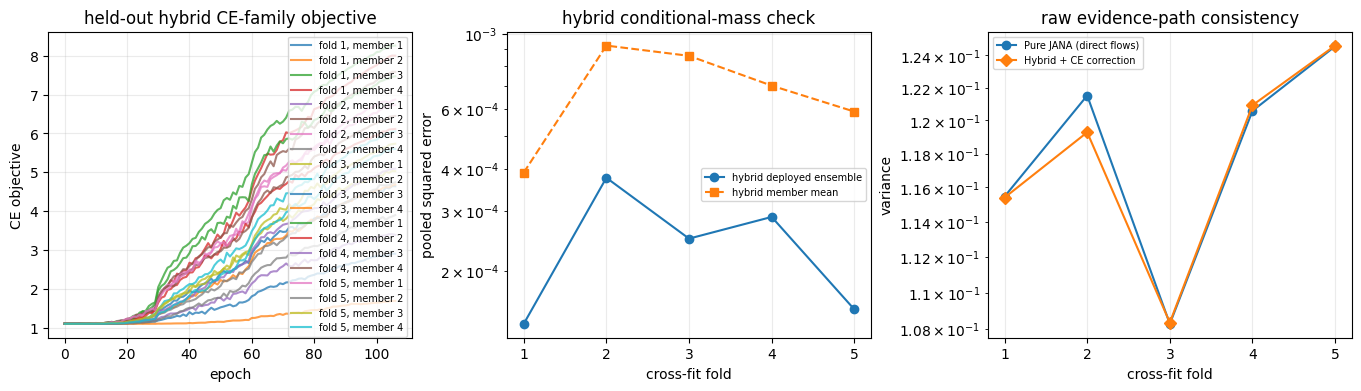

Saved paired predictive diagnostics: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/results/gaussian_linear__v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_hybrid_ce__predictive_diagnostics.csv
Saved paired posterior samples: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/results/gaussian_linear__v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_hybrid_ce__observation1__posterior_samples.npz
gaussian_linear observation 1: 2,000 shared evaluation-only simulator calls (outside the 100,000-call training bank).
Saved paired predictive samples: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/results/gaussian_linear__v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_hybrid_ce__observation1__predictive_samples.npz
Wrote standalone figure script: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/figures_scripts/gaussian_linear/v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d

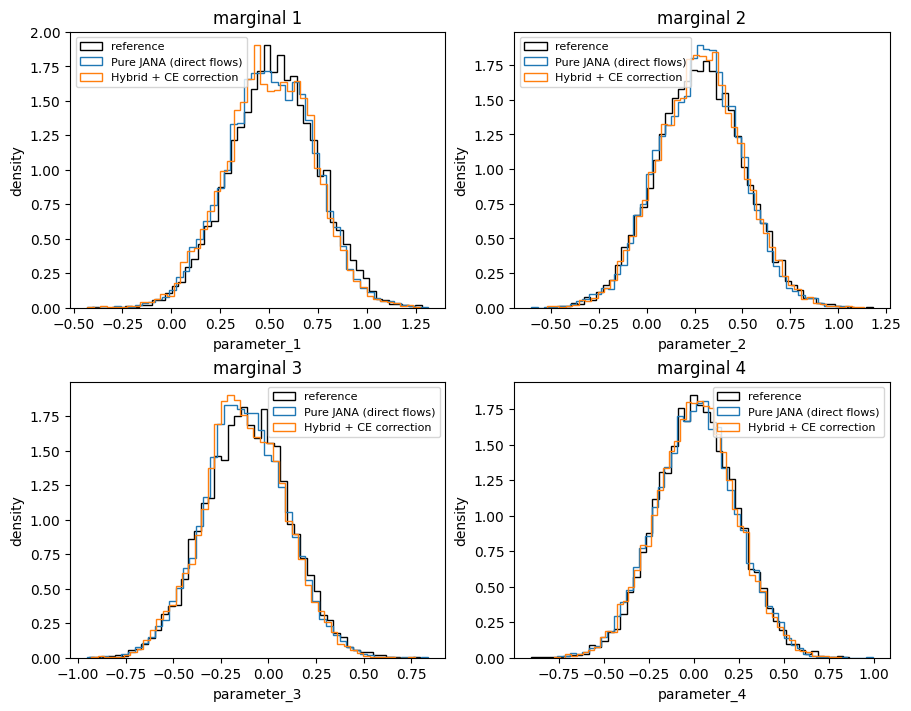

Wrote standalone figure script: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/figures_scripts/gaussian_linear/v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_hybrid_ce/predictive_observation_1.py
Exported: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/figures_scripts/gaussian_linear/v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_hybrid_ce/predictive_observation_1.py


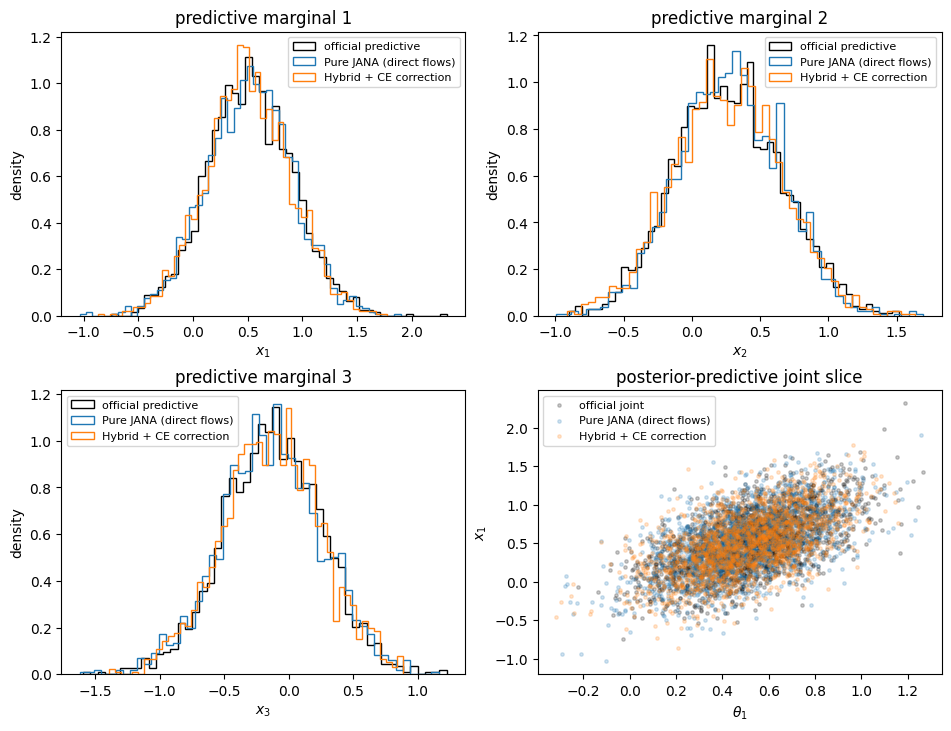

Saved paired posterior samples: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/results/gaussian_linear__v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_hybrid_ce__observation2__posterior_samples.npz
gaussian_linear observation 2: 2,000 shared evaluation-only simulator calls (outside the 100,000-call training bank).
Saved paired predictive samples: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/results/gaussian_linear__v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_hybrid_ce__observation2__predictive_samples.npz
Wrote standalone figure script: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/figures_scripts/gaussian_linear/v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_hybrid_ce/posterior_observation_2.py
Exported: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/figures_scripts/gaussian_linear/v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_h

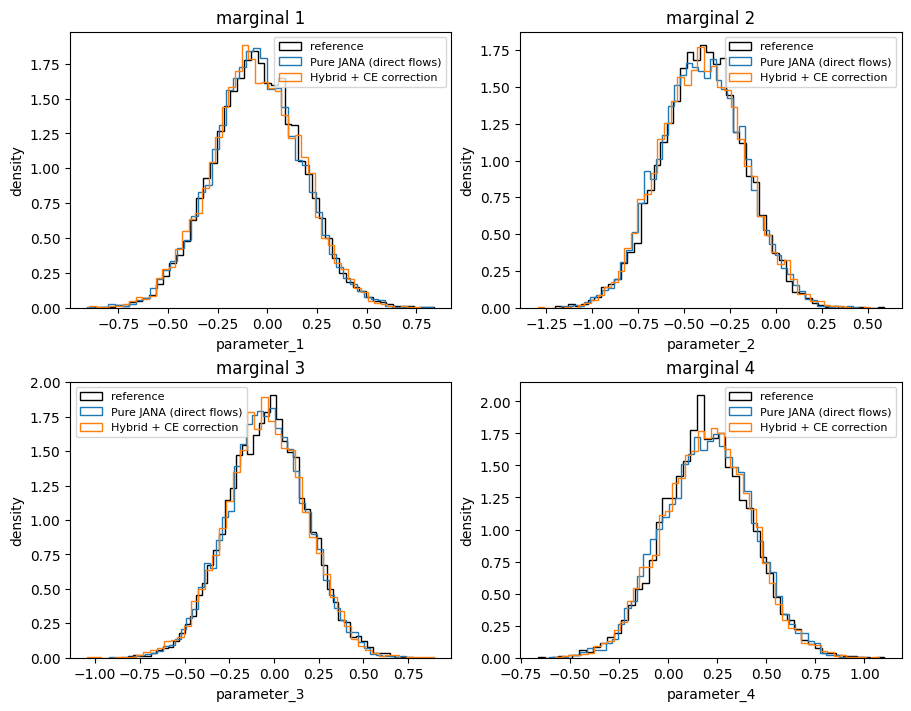

Wrote standalone figure script: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/figures_scripts/gaussian_linear/v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_hybrid_ce/predictive_observation_2.py
Exported: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/figures_scripts/gaussian_linear/v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_hybrid_ce/predictive_observation_2.py


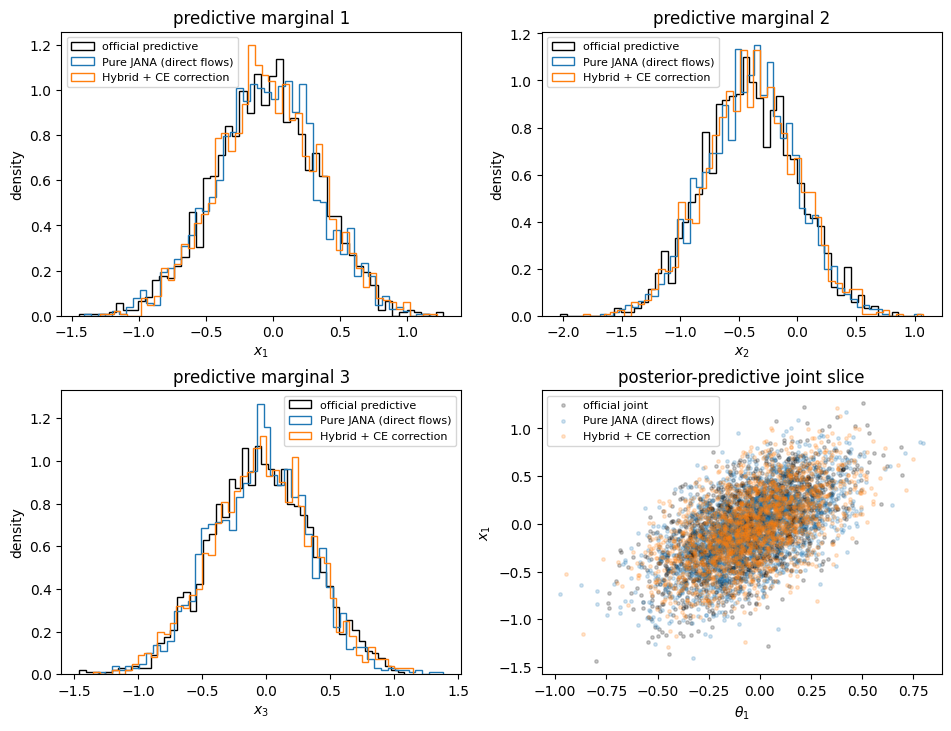

Saved paired posterior samples: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/results/gaussian_linear__v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_hybrid_ce__observation3__posterior_samples.npz
gaussian_linear observation 3: 2,000 shared evaluation-only simulator calls (outside the 100,000-call training bank).
Saved paired predictive samples: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/results/gaussian_linear__v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_hybrid_ce__observation3__predictive_samples.npz
Wrote standalone figure script: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/figures_scripts/gaussian_linear/v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_hybrid_ce/posterior_observation_3.py
Exported: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/figures_scripts/gaussian_linear/v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_h

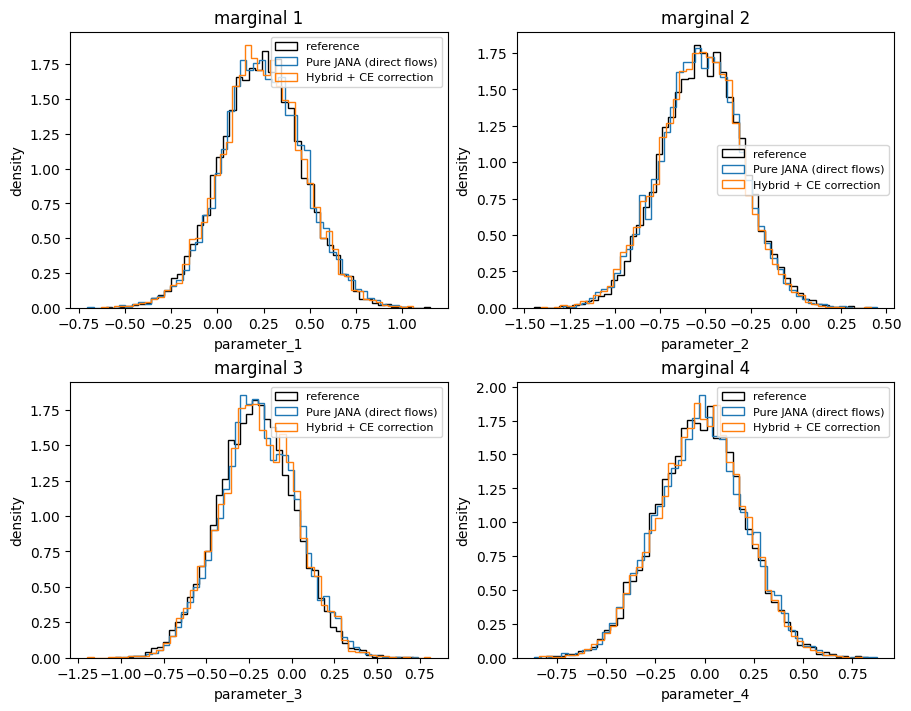

Wrote standalone figure script: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/figures_scripts/gaussian_linear/v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_hybrid_ce/predictive_observation_3.py
Exported: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/figures_scripts/gaussian_linear/v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_hybrid_ce/predictive_observation_3.py


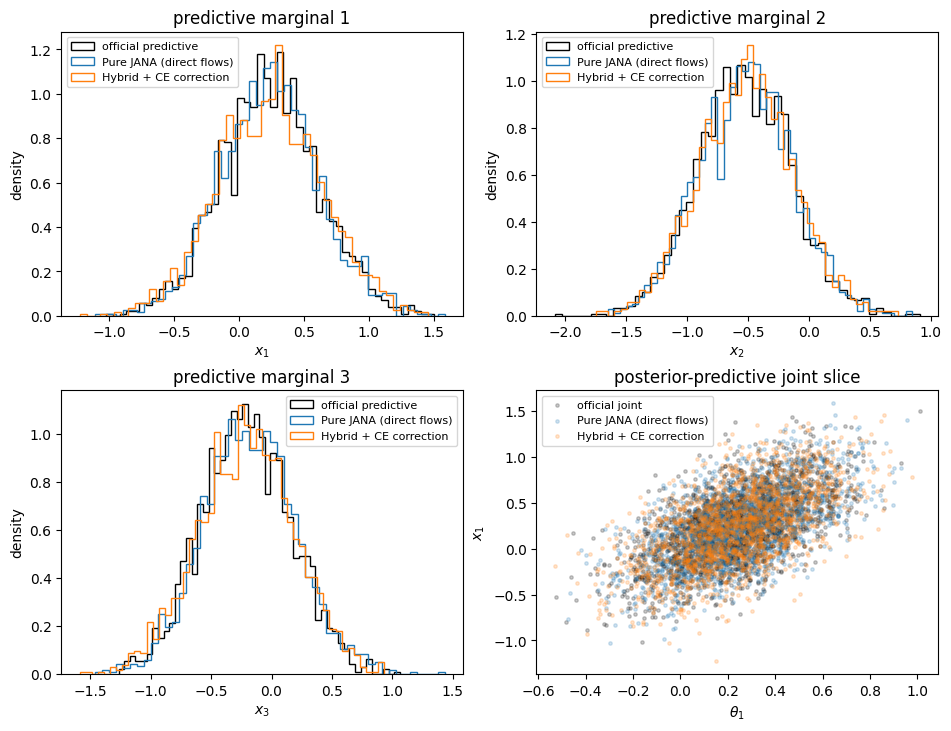

Saved paired posterior samples: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/results/gaussian_linear__v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_hybrid_ce__observation4__posterior_samples.npz
gaussian_linear observation 4: 2,000 shared evaluation-only simulator calls (outside the 100,000-call training bank).
Saved paired predictive samples: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/results/gaussian_linear__v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_hybrid_ce__observation4__predictive_samples.npz
Wrote standalone figure script: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/figures_scripts/gaussian_linear/v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_hybrid_ce/posterior_observation_4.py
Exported: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/figures_scripts/gaussian_linear/v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_h

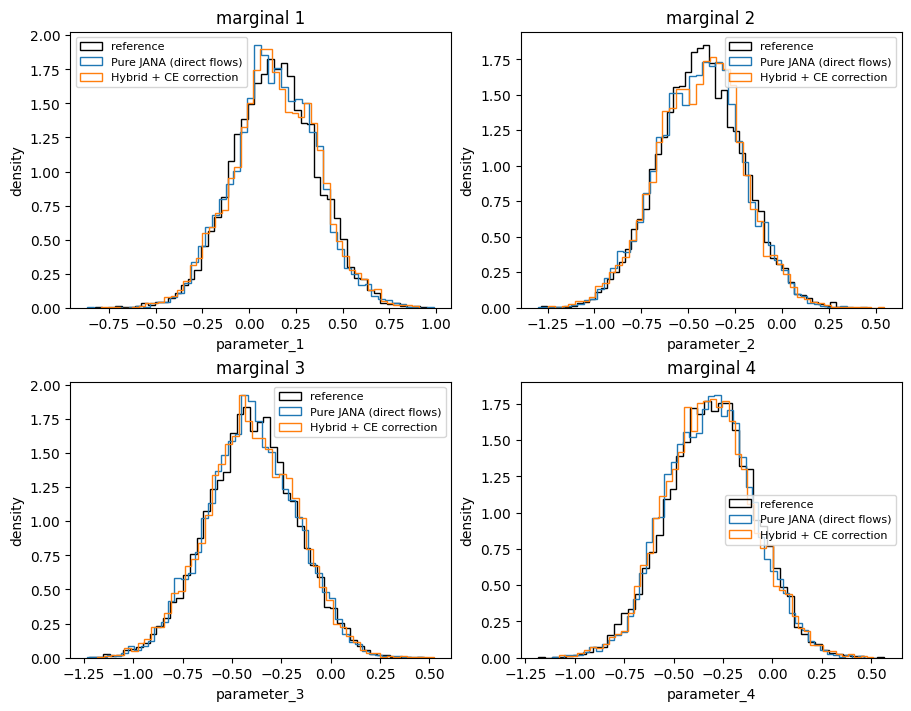

Wrote standalone figure script: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/figures_scripts/gaussian_linear/v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_hybrid_ce/predictive_observation_4.py
Exported: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/figures_scripts/gaussian_linear/v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_hybrid_ce/predictive_observation_4.py


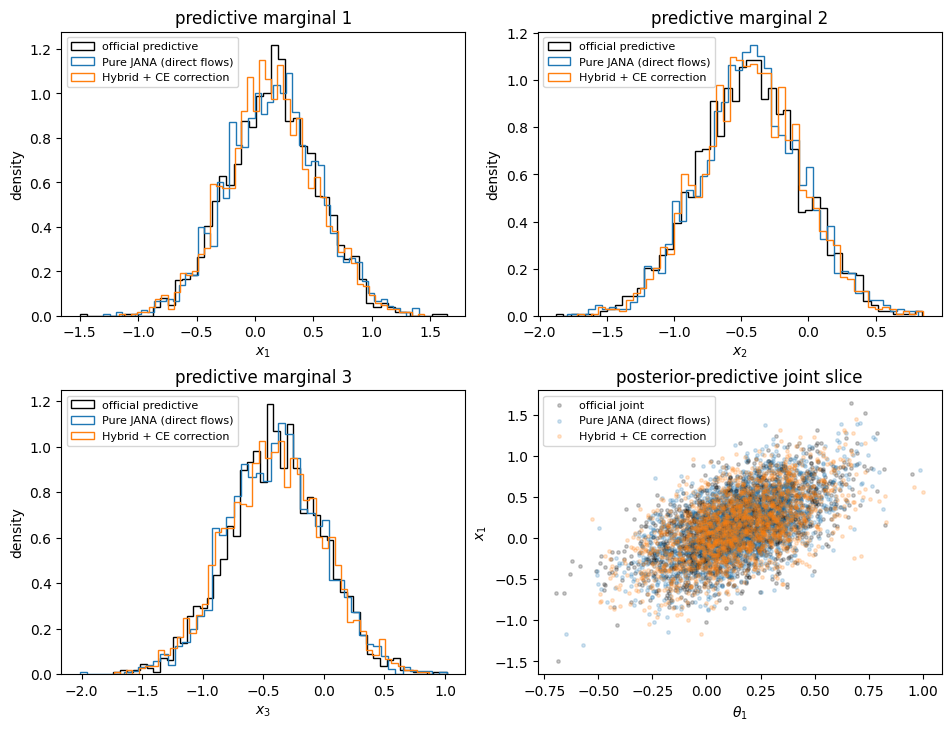

Saved paired posterior samples: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/results/gaussian_linear__v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_hybrid_ce__observation5__posterior_samples.npz
gaussian_linear observation 5: 2,000 shared evaluation-only simulator calls (outside the 100,000-call training bank).
Saved paired predictive samples: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/results/gaussian_linear__v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_hybrid_ce__observation5__predictive_samples.npz
Wrote standalone figure script: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/figures_scripts/gaussian_linear/v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_hybrid_ce/posterior_observation_5.py
Exported: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/figures_scripts/gaussian_linear/v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_h

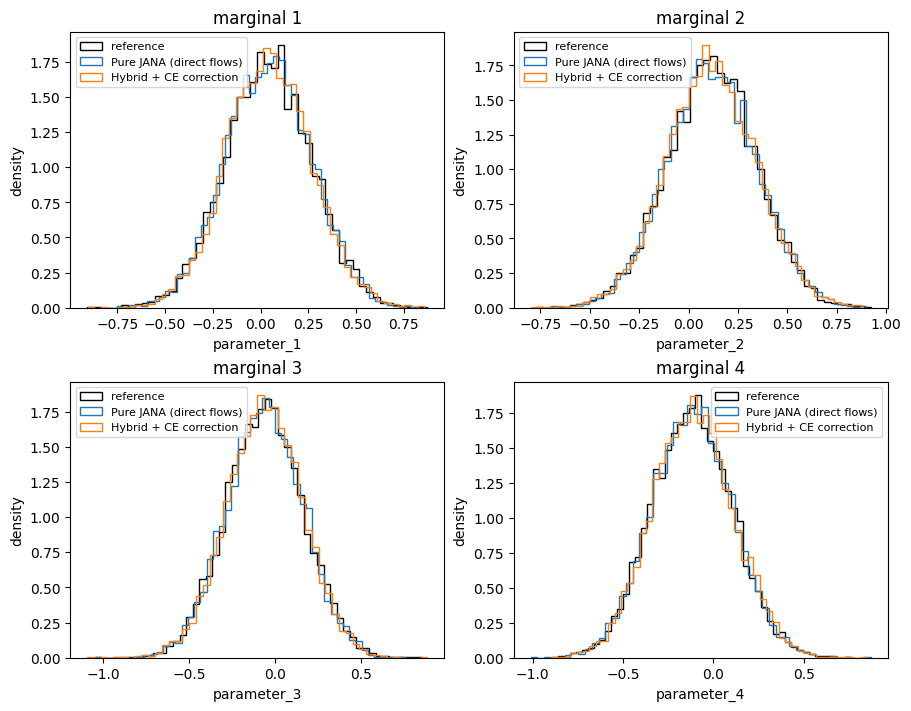

Wrote standalone figure script: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/figures_scripts/gaussian_linear/v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_hybrid_ce/predictive_observation_5.py
Exported: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/figures_scripts/gaussian_linear/v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_hybrid_ce/predictive_observation_5.py


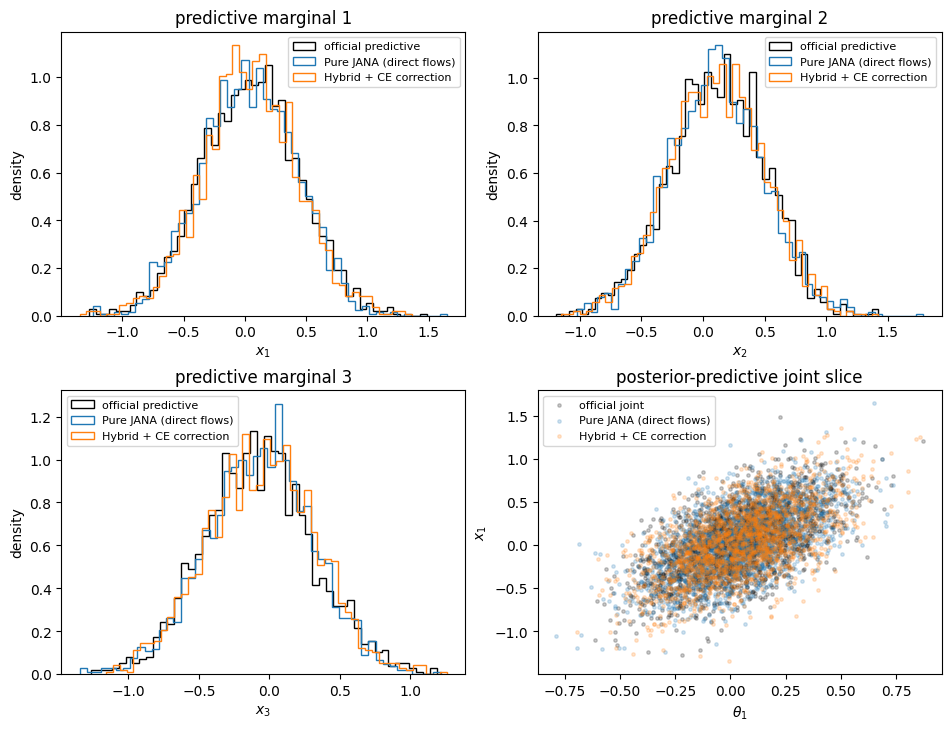

Saved paired posterior samples: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/results/gaussian_linear__v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_hybrid_ce__observation6__posterior_samples.npz
gaussian_linear observation 6: 2,000 shared evaluation-only simulator calls (outside the 100,000-call training bank).
Saved paired predictive samples: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/results/gaussian_linear__v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_hybrid_ce__observation6__predictive_samples.npz
Wrote standalone figure script: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/figures_scripts/gaussian_linear/v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_hybrid_ce/posterior_observation_6.py
Exported: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/figures_scripts/gaussian_linear/v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_h

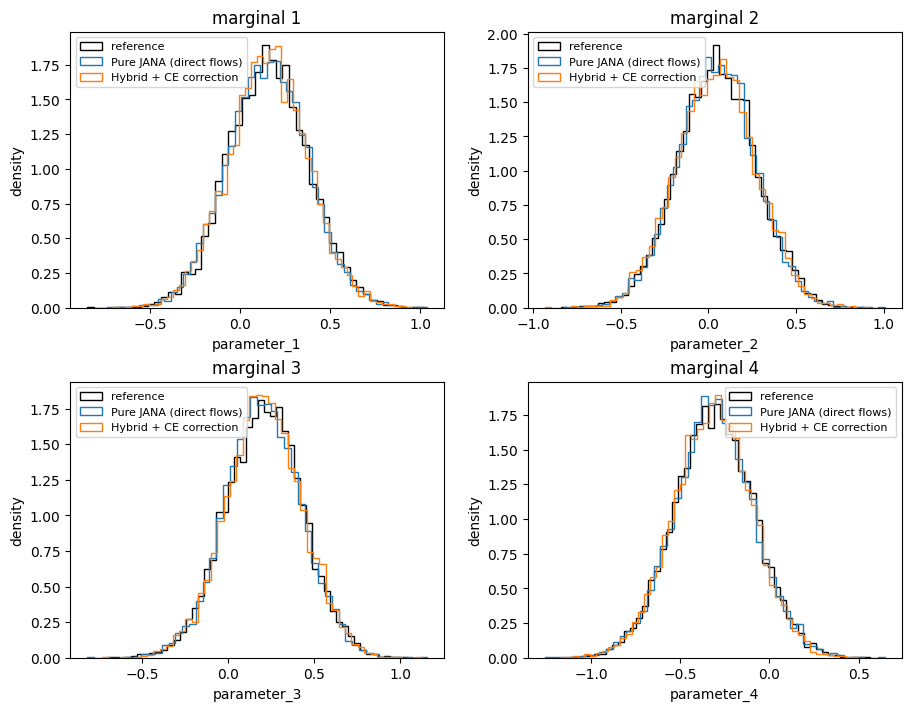

Wrote standalone figure script: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/figures_scripts/gaussian_linear/v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_hybrid_ce/predictive_observation_6.py
Exported: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/figures_scripts/gaussian_linear/v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_hybrid_ce/predictive_observation_6.py


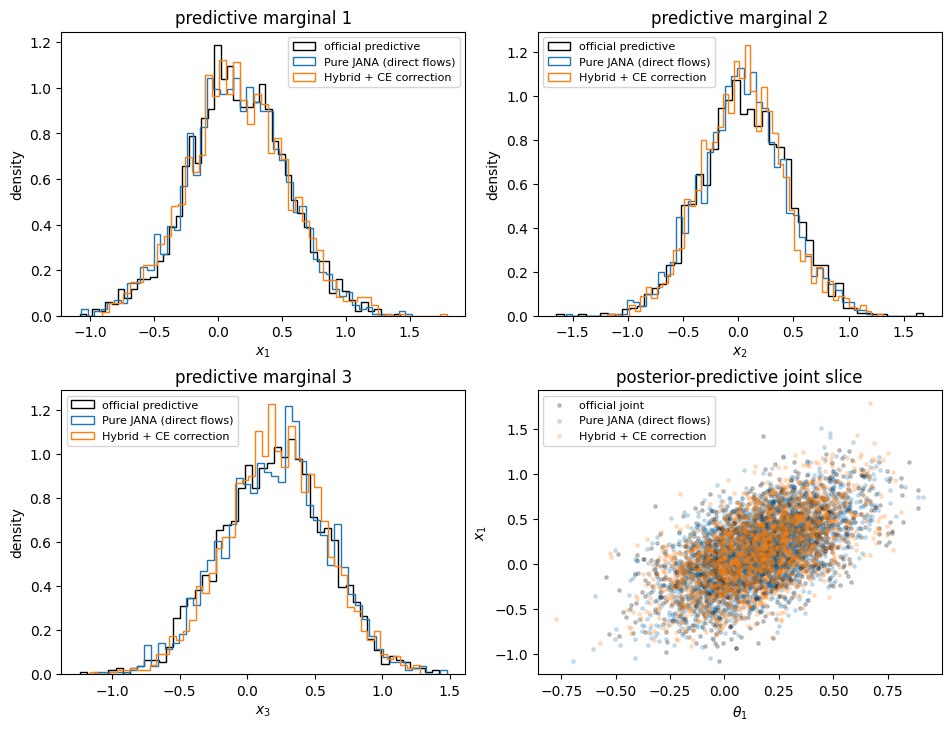

Saved paired posterior samples: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/results/gaussian_linear__v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_hybrid_ce__observation7__posterior_samples.npz
gaussian_linear observation 7: 2,000 shared evaluation-only simulator calls (outside the 100,000-call training bank).
Saved paired predictive samples: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/results/gaussian_linear__v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_hybrid_ce__observation7__predictive_samples.npz
Wrote standalone figure script: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/figures_scripts/gaussian_linear/v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_hybrid_ce/posterior_observation_7.py
Exported: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/figures_scripts/gaussian_linear/v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_h

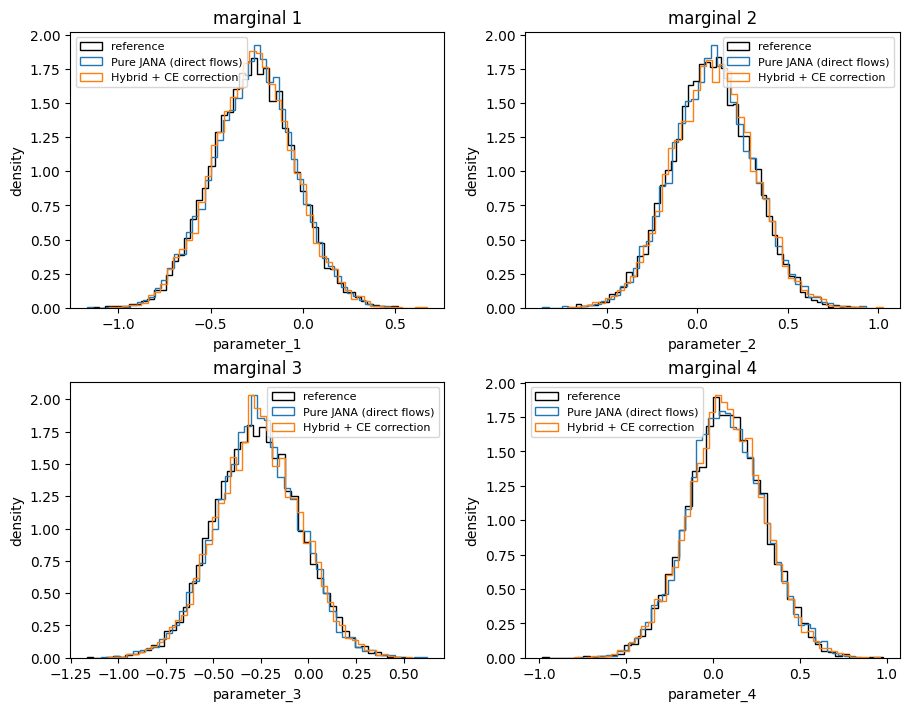

Wrote standalone figure script: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/figures_scripts/gaussian_linear/v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_hybrid_ce/predictive_observation_7.py
Exported: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/figures_scripts/gaussian_linear/v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_hybrid_ce/predictive_observation_7.py


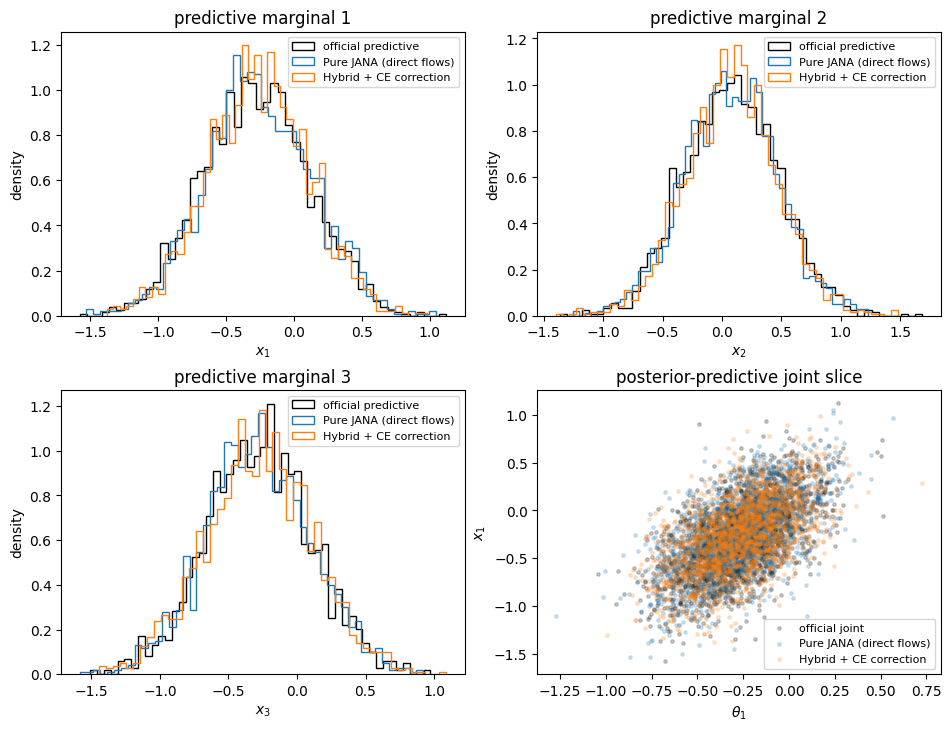

Saved paired posterior samples: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/results/gaussian_linear__v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_hybrid_ce__observation8__posterior_samples.npz
gaussian_linear observation 8: 2,000 shared evaluation-only simulator calls (outside the 100,000-call training bank).
Saved paired predictive samples: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/results/gaussian_linear__v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_hybrid_ce__observation8__predictive_samples.npz
Wrote standalone figure script: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/figures_scripts/gaussian_linear/v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_hybrid_ce/posterior_observation_8.py
Exported: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/figures_scripts/gaussian_linear/v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_h

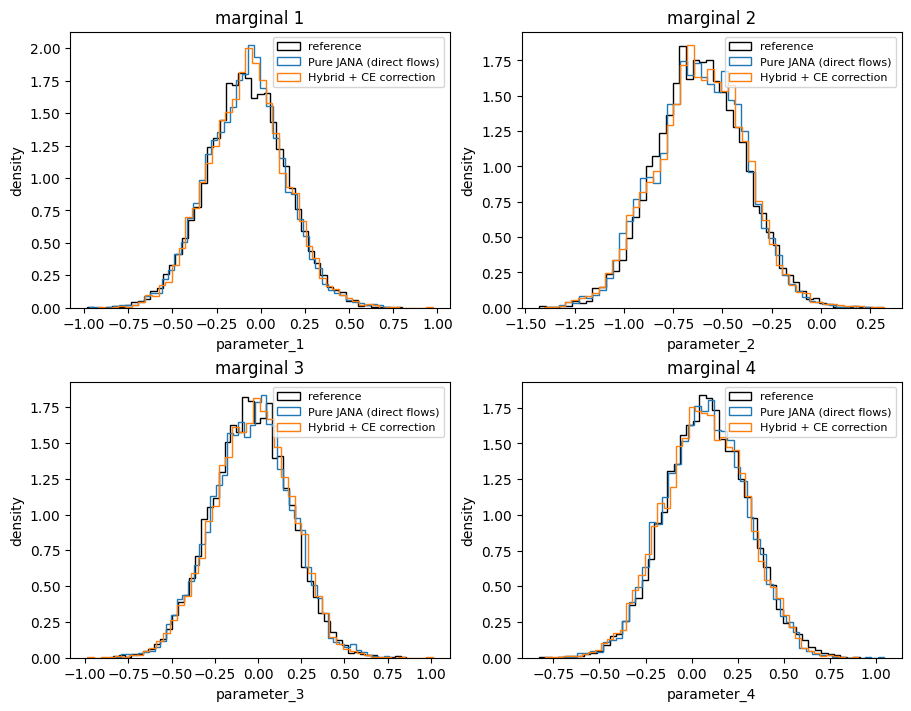

Wrote standalone figure script: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/figures_scripts/gaussian_linear/v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_hybrid_ce/predictive_observation_8.py
Exported: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/figures_scripts/gaussian_linear/v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_hybrid_ce/predictive_observation_8.py


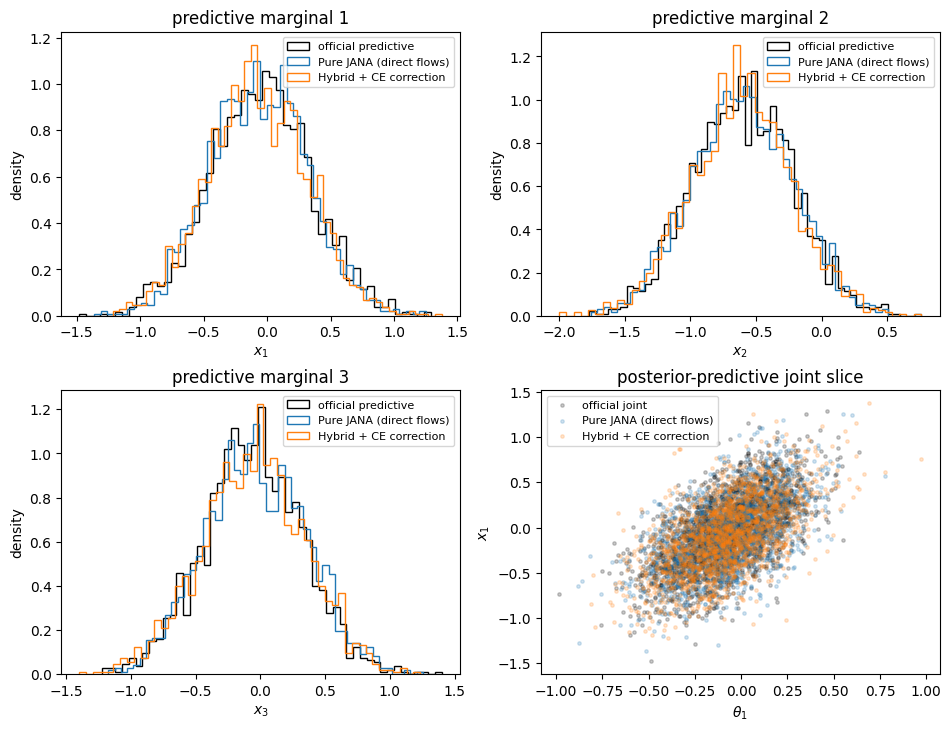

Saved paired posterior samples: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/results/gaussian_linear__v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_hybrid_ce__observation9__posterior_samples.npz
gaussian_linear observation 9: 2,000 shared evaluation-only simulator calls (outside the 100,000-call training bank).
Saved paired predictive samples: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/results/gaussian_linear__v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_hybrid_ce__observation9__predictive_samples.npz
Wrote standalone figure script: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/figures_scripts/gaussian_linear/v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_hybrid_ce/posterior_observation_9.py
Exported: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/figures_scripts/gaussian_linear/v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_h

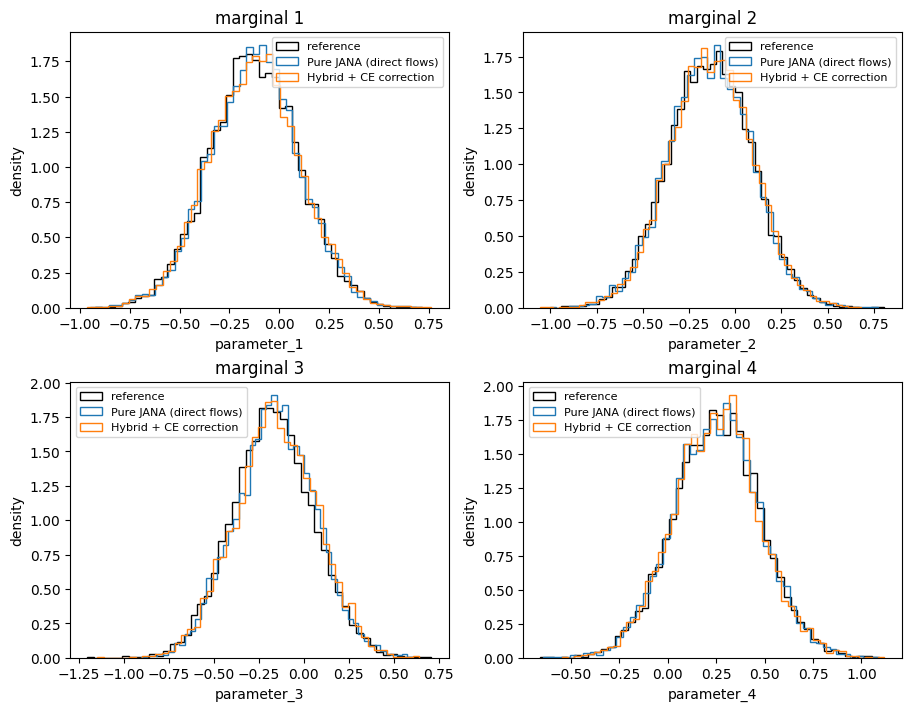

Wrote standalone figure script: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/figures_scripts/gaussian_linear/v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_hybrid_ce/predictive_observation_9.py
Exported: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/figures_scripts/gaussian_linear/v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_hybrid_ce/predictive_observation_9.py


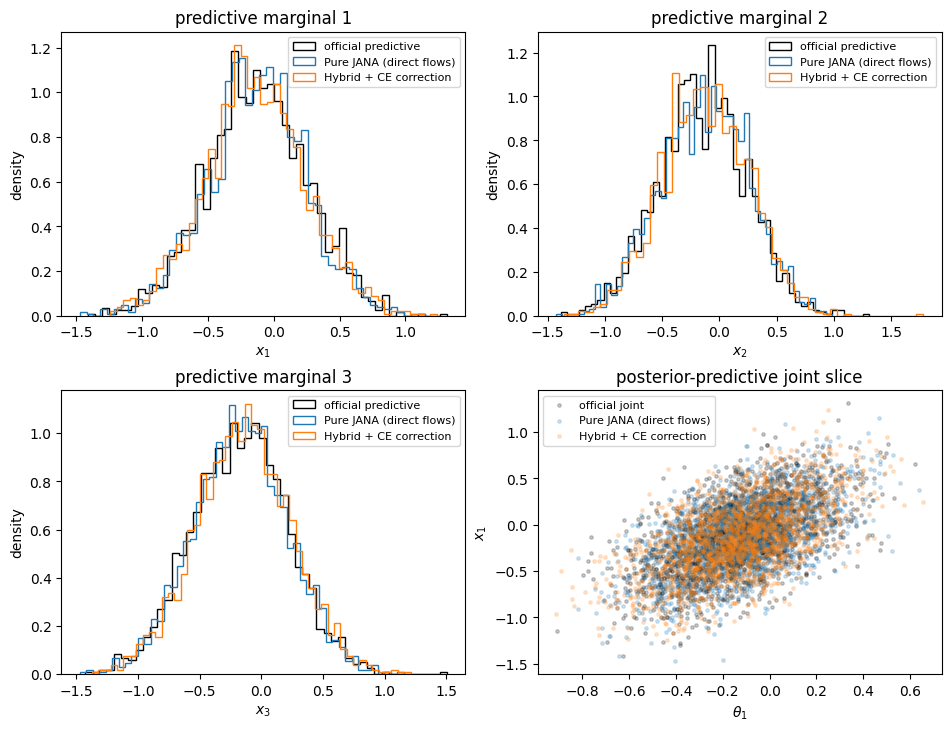

Saved paired posterior samples: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/results/gaussian_linear__v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_hybrid_ce__observation10__posterior_samples.npz
gaussian_linear observation 10: 2,000 shared evaluation-only simulator calls (outside the 100,000-call training bank).
Saved paired predictive samples: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/results/gaussian_linear__v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_hybrid_ce__observation10__predictive_samples.npz
Wrote standalone figure script: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/figures_scripts/gaussian_linear/v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_hybrid_ce/posterior_observation_10.py
Exported: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/figures_scripts/gaussian_linear/v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_ja

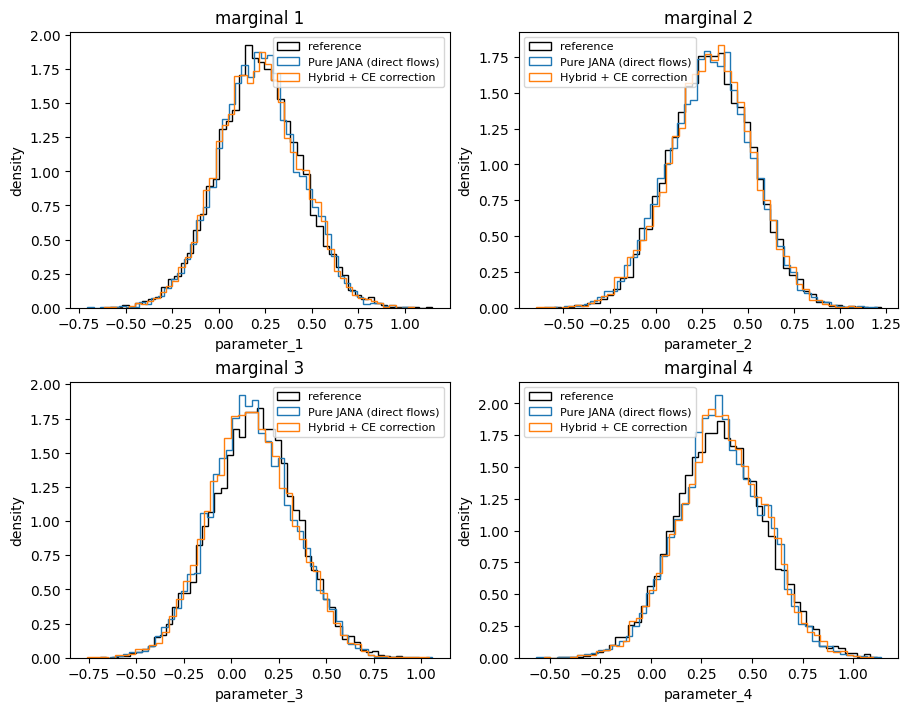

Wrote standalone figure script: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/figures_scripts/gaussian_linear/v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_hybrid_ce/predictive_observation_10.py
Exported: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/figures_scripts/gaussian_linear/v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_hybrid_ce/predictive_observation_10.py


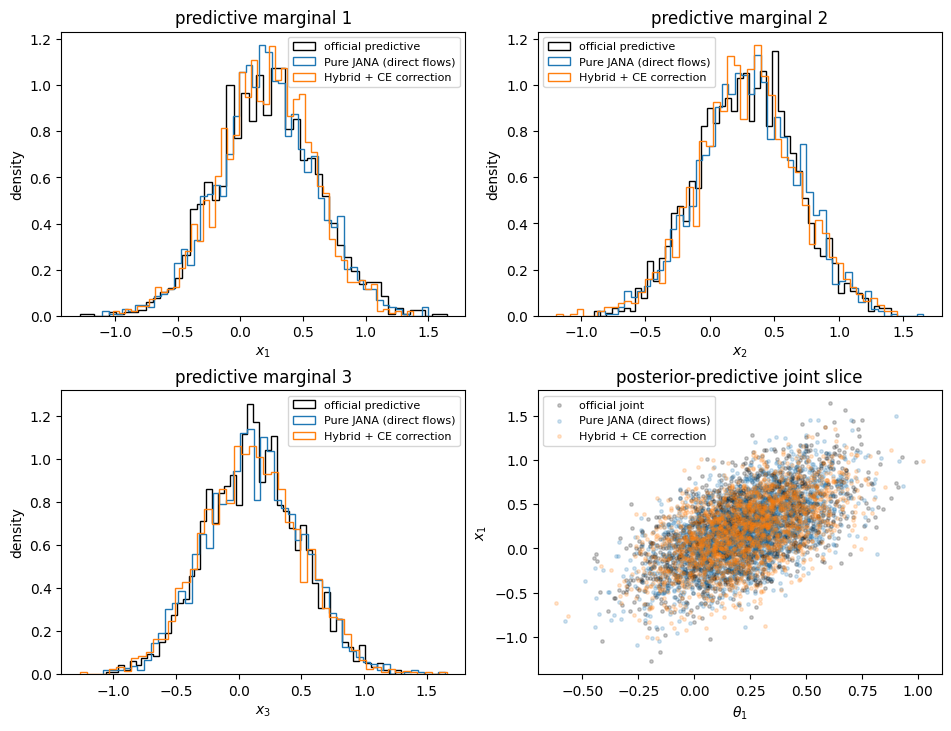

Saved paired long-form metrics: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/results/gaussian_linear__v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_hybrid_ce__metrics.csv


task,profile,run_tag,seed,campaign_schema,campaign_signature,metric_schema,jana_paper_commit,method,method_label,num_simulations,num_observation,data_semantics,dequantization_exact_unit_cell,dequantization_width_min,dequantization_width_max,classifier_objective,checkpoint_objective,normalization_role,bridge_role,uses_ce_correction,posterior_method,predictive_method,predictive_candidate_allocation,predictive_candidates_per_theta,predictive_evaluation_simulator_calls,predictive_reference_shared_between_methods,predictive_simulator_calls_in_training,predictive_candidate_max_weight_worst,predictive_candidate_ESS_fraction_min_over_theta,C2ST,MMD2,MMD,posterior_C2ST,posterior_MMD2,posterior_MMD,posterior_MMD_bandwidth2,posterior_MMD_n,posterior_MMD_bandwidth_source,predictive_x_C2ST,predictive_x_MMD2,predictive_x_MMD,predictive_x_MMD_bandwidth2,predictive_x_MMD_n,predictive_x_MMD_bandwidth_source,predictive_joint_C2ST,predictive_joint_MMD2,predictive_joint_MMD,predictive_joint_MMD_bandwidth2,predictive_joint_MMD_n,predictive_joint_MMD_bandwidth_source,mean_hybrid_ESS,mean_hybrid_ESS_fraction,mean_hybrid_max_weight,mean_hybrid_posthoc_rms_log_ZP,mean_hybrid_observation_jitters,mean_hybrid_shared_q_phi_proposal_rows,mean_hybrid_audit_norm_cross,mean_hybrid_audit_norm_monitor,mean_hybrid_audit_bridge,mean_jana_audit_bridge,mean_predictive_candidate_count,mean_predictive_outputs,mean_predictive_candidate_ESS_mean,mean_predictive_candidate_ESS_fraction_mean,mean_predictive_candidate_ESS_fraction_min_over_theta,mean_predictive_candidate_max_weight_mean,mean_predictive_candidate_max_weight_worst,mean_predictive_posthoc_candidate_log_ZL_rms
gaussian_linear,FULL,v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_hybrid_ce,29082026,structured_v9_paired_jana_hybrid_ce_post_training_checks,sha256-3fd6d89c19ad,paired_long_reference_bandwidth_v1,6cbbc94faf0aa85147986f7f9516d13a52551bd4,jana_direct,Pure JANA (direct flows),100000,1,continuous_density,False,0.0000,0.0000,none_pure_JANA_flow_NLL,held_out_flow_NLL,normalized_flow_density_no_ratio_correction,held_out_consistency_check_only,False,direct_q_phi,direct_q_eta,iid,1,2000,True,0,nan,nan,0.5073,0.0008,0.0281,0.5073,0.0008,0.0281,18.6206,2000,reference_only_shared,0.5142,0.0002,0.0153,18.4590,2000,reference_only_shared,0.5025,0.0005,0.0213,38.1009,2000,reference_only_shared,149920.8716,0.9995,0.0000,0.0145,1.0000,150000.0000,0.0002,0.0002,0.1177,0.1181,nan,nan,nan,nan,nan,nan,nan,nan
gaussian_linear,FULL,v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_hybrid_ce,29082026,structured_v9_paired_jana_hybrid_ce_post_training_checks,sha256-3fd6d89c19ad,paired_long_reference_bandwidth_v1,6cbbc94faf0aa85147986f7f9516d13a52551bd4,hybrid_ce,Hybrid + CE correction,100000,1,continuous_density,False,0.0000,0.0000,multiclass_CE_plus_direct_a_binary_CE,held_out_CE_family_only,post_training_self_normalized_finite_proposals_and_check,held_out_consistency_check_only,True,q_phi_exp_a_finite_proposal,q_eta_exp_c_finite_K_SIR,iid,16,2000,True,0,0.0736,0.9959,0.5105,0.0007,0.0260,0.5105,0.0007,0.0260,18.6206,2000,reference_only_shared,0.5197,0.0003,0.0186,18.4590,2000,reference_only_shared,0.5285,0.0005,0.0233,38.1009,2000,reference_only_shared,149920.8716,0.9995,0.0000,0.0145,1.0000,150000.0000,0.0002,0.0002,0.1177,0.1181,16.0000,400.0000,15.9964,0.9998,0.9988,0.0640,0.0669,0.0132
gaussian_linear,FULL,v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_hybrid_ce,29082026,structured_v9_paired_jana_hybrid_ce_post_training_checks,sha256-3fd6d89c19ad,paired_long_reference_bandwidth_v1,6cbbc94faf0aa85147986f7f9516d13a52551bd4,jana_direct,Pure JANA (direct flows),100000,2,continuous_density,False,0.0000,0.0000,none_pure_JANA_flow_NLL,held_out_flow_NLL,normalized_flow_density_no_ratio_correction,held_out_consistency_check_only,False,direct_q_phi,direct_q_eta,iid,1,2000,True,0,nan,nan,0.5040,0.0008,0.0285,0.5040,0.0008,0.0285,18.2811,2000,referenc

Wrote status manifest: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/results/gaussian_linear__v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_hybrid_ce__status.json

gaussian_linear_uniform: exact persistent cache path is /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/simulation_banks/gaussian_linear_uniform_prior_predictive_100000_seed29182026.npz
Saved exactly 100,000 simulations to /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/simulation_banks/gaussian_linear_uniform_prior_predictive_100000_seed29182026.npz

gaussian_linear_uniform: cross-fit fold 1/5
Flow-mixture member 1/4: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9b_SBIBM/models/gaussian_linear_uniform/v9_full_seed29082026_n100000_k5_flowmix4_cfgsha256-3fd6d89c19ad_paired_jana_hybrid_ce/fold_00/q_phi.member_00.pt
Training conditional quadratic-spline flow on 68,000 rows
  epoch 01/90: train=8.0179, validation=7.4279
  epoch 02/90: train=7.2944, validation=7.3091
  epo

In [ ]:
campaign_results = []
campaign_failures = []
for selected_task in TASKS_TO_RUN:
    status_path = RESULT_ROOT / f"{selected_task}__{RUN_TAG}__status.json"
    try:
        result = train_and_evaluate_task(selected_task)
        campaign_results.append(result)
        status = {
            "task": selected_task, "profile": PROFILE, "seed": SEED,
            "run_tag": RUN_TAG, "campaign_schema": CAMPAIGN_SCHEMA,
            "campaign_signature": CAMPAIGN_SIGNATURE,
            "metric_schema": METRIC_SCHEMA,
            "jana_paper_commit": JANA_PAPER_COMMIT,
            "methods": list(METHODS),
            "jana_baseline": "matched_crossfit_qphi_qeta_direct_no_classifier",
            "hybrid_classifier_objective": "multiclass_CE_plus_direct_a_binary_CE",
            "hybrid_checkpoint_objective": "held_out_CE_family_only",
            "normalization_role": "post_training_hybrid_only",
            "bridge_role": "paired_held_out_check_only",
            "status": "completed",
        }
    except Exception as exc:
        status = {
            "task": selected_task, "profile": PROFILE, "seed": SEED,
            "run_tag": RUN_TAG, "campaign_schema": CAMPAIGN_SCHEMA,
            "campaign_signature": CAMPAIGN_SIGNATURE,
            "metric_schema": METRIC_SCHEMA,
            "jana_paper_commit": JANA_PAPER_COMMIT,
            "methods": list(METHODS),
            "jana_baseline": "matched_crossfit_qphi_qeta_direct_no_classifier",
            "hybrid_classifier_objective": "multiclass_CE_plus_direct_a_binary_CE",
            "hybrid_checkpoint_objective": "held_out_CE_family_only",
            "normalization_role": "post_training_hybrid_only",
            "bridge_role": "paired_held_out_check_only",
            "status": "failed", "exception_type": type(exc).__name__,
            "message": str(exc), "traceback": traceback.format_exc(),
        }
        campaign_failures.append(status)
        print(status["traceback"])
    status_path.write_text(json.dumps(status, indent=2), encoding="utf-8")
    print("Wrote status manifest:", status_path)

if campaign_failures:
    failure_table = pd.DataFrame(campaign_failures).drop(columns="traceback")
    display(failure_table)
    if FAIL_ON_TASK_ERROR:
        raise RuntimeError(
            "One or more requested sbibm tasks failed. No task was silently skipped; "
            "see the displayed table and per-task status JSON."
        )


## 5. Ten-task aggregate: paired JANA versus hybrid CE

JANA Figure 5 compares posterior MMD and posterior-predictive MMD.  Its “joint” panel evaluates generated $x_{\rm rep}$ samples, not a concatenated $(\theta,x_{\rm rep})$ vector.  The headline figure below therefore uses **posterior MMD** and **$x$-only posterior-predictive MMD**.  We retain concatenated $(\theta,x_{\rm rep})$ MMD and C2ST as supplemental tests.

Every MMD pair shares the exact same reference subset, reference standardization, and a median-heuristic Gaussian bandwidth computed from the reference only.  The CSV is long-form (`method` is part of the primary key), and the paired table reports $\log_{10}(\mathrm{MMD}_{\rm hybrid}/\mathrm{MMD}_{\rm JANA})$: negative values favor the CE correction.  This campaign extends Figure 5's posterior/predictive logic across the ten `sbibm` tasks; it is not a numerical reproduction of the historical Two-Moons software run.

By default this cell reads only files with the exact current `RUN_TAG`.  For a paper campaign, set `EX9B_AGGREGATE_SEEDS=29082026,29082027,...`; incompatible schemas, incomplete method pairs, duplicated rows, and missing task-seed pairs are rejected or reported explicitly.


In [ ]:
candidate_metric_files = sorted({
    path
    for aggregate_run_tag in AGGREGATE_RUN_TAGS
    for path in RESULT_ROOT.glob(f"*__{aggregate_run_tag}__metrics.csv")
})
tag_to_seed = dict(zip(AGGREGATE_RUN_TAGS, AGGREGATE_SEEDS))
metric_frames = []
for path in candidate_metric_files:
    task_from_path, tag_from_path, suffix = path.name.rsplit("__", 2)
    if suffix != "metrics.csv" or tag_from_path not in tag_to_seed:
        raise RuntimeError(f"Unexpected aggregate metric path: {path}")
    expected_seed = tag_to_seed[tag_from_path]
    status_path = RESULT_ROOT / f"{task_from_path}__{tag_from_path}__status.json"
    if not status_path.exists():
        print("Excluding metric without status manifest:", path)
        continue
    status = json.loads(status_path.read_text(encoding="utf-8"))
    expected_status = {
        "task": task_from_path, "profile": PROFILE,
        "seed": expected_seed, "run_tag": tag_from_path,
        "campaign_schema": CAMPAIGN_SCHEMA,
        "campaign_signature": CAMPAIGN_SIGNATURE,
        "metric_schema": METRIC_SCHEMA,
        "jana_paper_commit": JANA_PAPER_COMMIT,
        "methods": list(METHODS),
        "jana_baseline": "matched_crossfit_qphi_qeta_direct_no_classifier",
        "hybrid_classifier_objective": "multiclass_CE_plus_direct_a_binary_CE",
        "hybrid_checkpoint_objective": "held_out_CE_family_only",
        "normalization_role": "post_training_hybrid_only",
        "bridge_role": "paired_held_out_check_only",
    }
    mismatched_status = {
        key: (status.get(key), value)
        for key, value in expected_status.items() if status.get(key) != value
    }
    if mismatched_status:
        raise RuntimeError(
            f"Status/configuration mismatch for {status_path}: {mismatched_status}"
        )
    if status.get("status") != "completed":
        print("Excluding metric whose latest status is not completed:", path)
        continue

    frame = pd.read_csv(path)
    required = {
        "task", "profile", "seed", "run_tag", "campaign_schema",
        "campaign_signature", "metric_schema", "jana_paper_commit",
        "method", "method_label",
        "num_simulations", "num_observation", "posterior_MMD",
        "predictive_x_MMD", "predictive_joint_MMD", "posterior_C2ST",
        "predictive_x_C2ST", "predictive_joint_C2ST",
        "posterior_MMD_bandwidth_source", "predictive_x_MMD_bandwidth_source",
        "predictive_joint_MMD_bandwidth_source", "classifier_objective",
        "checkpoint_objective", "normalization_role", "uses_ce_correction",
    }
    if frame.empty or not required.issubset(frame.columns):
        raise RuntimeError(f"Incomplete paired aggregate metric schema: {path}")
    common_contract = {
        "task": {task_from_path}, "profile": {PROFILE},
        "seed": {int(expected_seed)}, "run_tag": {tag_from_path},
        "campaign_schema": {CAMPAIGN_SCHEMA},
        "campaign_signature": {CAMPAIGN_SIGNATURE},
        "metric_schema": {METRIC_SCHEMA},
        "jana_paper_commit": {JANA_PAPER_COMMIT},
        "num_simulations": {int(campaign['num_simulations'])},
        "method": set(METHODS),
    }
    observed_contract = {
        "task": set(frame["task"].astype(str)),
        "profile": set(frame["profile"].astype(str)),
        "seed": set(frame["seed"].astype(int)),
        "run_tag": set(frame["run_tag"].astype(str)),
        "campaign_schema": set(frame["campaign_schema"].astype(str)),
        "campaign_signature": set(frame["campaign_signature"].astype(str)),
        "metric_schema": set(frame["metric_schema"].astype(str)),
        "jana_paper_commit": set(frame["jana_paper_commit"].astype(str)),
        "num_simulations": set(frame["num_simulations"].astype(int)),
        "method": set(frame["method"].astype(str)),
    }
    if observed_contract != common_contract:
        raise RuntimeError(
            f"Refusing to mix incompatible metric file {path}: "
            f"observed={observed_contract}, expected={common_contract}"
        )
    method_contracts = {
        METHOD_JANA: {
            "method_label": METHOD_LABELS[METHOD_JANA],
            "classifier_objective": "none_pure_JANA_flow_NLL",
            "checkpoint_objective": "held_out_flow_NLL",
            "normalization_role": "normalized_flow_density_no_ratio_correction",
            "uses_ce_correction": False,
        },
        METHOD_HYBRID: {
            "method_label": METHOD_LABELS[METHOD_HYBRID],
            "classifier_objective": "multiclass_CE_plus_direct_a_binary_CE",
            "checkpoint_objective": "held_out_CE_family_only",
            "normalization_role": "post_training_self_normalized_finite_proposals_and_check",
            "uses_ce_correction": True,
        },
    }
    for method, contract in method_contracts.items():
        method_frame = frame.loc[frame["method"] == method]
        for column, expected_value in contract.items():
            values = set(method_frame[column])
            if values != {expected_value}:
                raise RuntimeError(
                    f"Method contract mismatch for {method} in {path}: "
                    f"{column}={values}, expected={expected_value!r}"
                )
    if set(frame["posterior_MMD_bandwidth_source"]) != {"reference_only_shared"}:
        raise RuntimeError(f"Non-shared posterior MMD bandwidth in {path}")
    if set(frame["predictive_x_MMD_bandwidth_source"]) != {"reference_only_shared"}:
        raise RuntimeError(f"Non-shared predictive MMD bandwidth in {path}")
    if set(frame["predictive_joint_MMD_bandwidth_source"]) != {"reference_only_shared"}:
        raise RuntimeError(f"Non-shared concatenated-joint MMD bandwidth in {path}")
    for bandwidth_column in [
        "posterior_MMD_bandwidth2", "predictive_x_MMD_bandwidth2",
        "predictive_joint_MMD_bandwidth2",
    ]:
        if frame.groupby("num_observation")[bandwidth_column].nunique().max() != 1:
            raise RuntimeError(
                f"Methods used different {bandwidth_column} values in {path}"
            )

    expected_observations = set(map(int, campaign["observations"]))
    for method in METHODS:
        method_frame = frame.loc[frame["method"] == method]
        observed_observations = set(method_frame["num_observation"].astype(int))
        duplicated_observations = method_frame["num_observation"].astype(int).duplicated().any()
        if observed_observations != expected_observations or duplicated_observations:
            raise RuntimeError(
                f"Incomplete or duplicated {method} rows in {path}: "
                f"observed={sorted(observed_observations)}, "
                f"expected={sorted(expected_observations)}, "
                f"duplicates={bool(duplicated_observations)}"
            )
    metric_frames.append(frame)

if not metric_frames:
    print("No completed paired metric files yet for", AGGREGATE_RUN_TAGS)
    aggregate_results = pd.DataFrame()
else:
    aggregate_results = pd.concat(metric_frames, ignore_index=True)
    aggregate_results = aggregate_results.loc[aggregate_results["task"].isin(ALL_TASKS)]
    key_columns = ["task", "seed", "num_observation", "method"]
    if aggregate_results.duplicated(key_columns).any():
        duplicate_rows = aggregate_results.loc[
            aggregate_results.duplicated(key_columns, keep=False), key_columns
        ]
        raise RuntimeError(f"Duplicate aggregate rows detected:\n{duplicate_rows}")
    completed_pairs = set(zip(
        aggregate_results["task"], aggregate_results["seed"].astype(int)
    ))
    expected_pairs = {(task, seed) for seed in AGGREGATE_SEEDS for task in ALL_TASKS}
    missing_pairs = sorted(
        expected_pairs - completed_pairs, key=lambda item: (item[1], item[0])
    )
    print("Completed task--seed pairs:", len(completed_pairs), "/", len(expected_pairs))
    print("Missing task--seed pairs (not silently averaged):", missing_pairs)
    print("complete=", not missing_pairs)

    summary = (
        aggregate_results.groupby(["task", "method", "method_label"], as_index=False)
        .agg(
            mean_posterior_MMD=("posterior_MMD", "mean"),
            std_posterior_MMD=("posterior_MMD", "std"),
            mean_predictive_x_MMD=("predictive_x_MMD", "mean"),
            std_predictive_x_MMD=("predictive_x_MMD", "std"),
            mean_predictive_joint_MMD=("predictive_joint_MMD", "mean"),
            std_predictive_joint_MMD=("predictive_joint_MMD", "std"),
            mean_posterior_C2ST=("posterior_C2ST", "mean"),
            mean_predictive_x_C2ST=("predictive_x_C2ST", "mean"),
            mean_predictive_joint_C2ST=("predictive_joint_C2ST", "mean"),
            observations=("num_observation", "nunique"),
            independent_seeds=("seed", "nunique"),
            metric_rows=("seed", "size"),
        )
    )
    paired_columns = [
        "posterior_MMD", "predictive_x_MMD", "predictive_joint_MMD",
        "posterior_C2ST", "predictive_x_C2ST", "predictive_joint_C2ST",
    ]
    paired = aggregate_results.pivot(
        index=["task", "seed", "num_observation"],
        columns="method", values=paired_columns,
    )
    paired.columns = [f"{metric}__{method}" for metric, method in paired.columns]
    paired = paired.reset_index()
    epsilon = 1.0e-12
    for metric in ["posterior_MMD", "predictive_x_MMD", "predictive_joint_MMD"]:
        paired[f"log10_hybrid_over_jana__{metric}"] = np.log10(
            (paired[f"{metric}__{METHOD_HYBRID}"] + epsilon)
            / (paired[f"{metric}__{METHOD_JANA}"] + epsilon)
        )
    for metric in ["posterior_C2ST", "predictive_x_C2ST", "predictive_joint_C2ST"]:
        paired[f"abs_error_hybrid_minus_jana__{metric}"] = (
            np.abs(paired[f"{metric}__{METHOD_HYBRID}"] - 0.5)
            - np.abs(paired[f"{metric}__{METHOD_JANA}"] - 0.5)
        )

    aggregate_dir = FIGURE_ROOT / "aggregate" / AGGREGATE_TAG
    aggregate_dir.mkdir(parents=True, exist_ok=True)
    aggregate_results.to_csv(aggregate_dir / "all_tasks_metrics_long.csv", index=False)
    summary.to_csv(aggregate_dir / "all_tasks_summary_by_method.csv", index=False)
    paired.to_csv(aggregate_dir / "all_tasks_paired_comparison.csv", index=False)
    (aggregate_dir / "aggregate_manifest.json").write_text(json.dumps({
        "profile": PROFILE, "campaign_schema": CAMPAIGN_SCHEMA,
        "campaign_signature": CAMPAIGN_SIGNATURE,
        "metric_schema": METRIC_SCHEMA,
        "methods": METHOD_LABELS,
        "jana_baseline": "matched_crossfit_qphi_qeta_direct_no_classifier",
        "jana_paper_commit": JANA_PAPER_COMMIT,
        "hybrid_classifier_objective": "multiclass_CE_plus_direct_a_binary_CE",
        "mmd_bandwidth": "reference_only_shared_within_each_method_pair",
        "headline_metrics": ["posterior_MMD", "predictive_x_MMD"],
        "supplemental_joint_metric": "predictive_joint_MMD_on_theta_x",
        "aggregate_seeds": AGGREGATE_SEEDS,
        "aggregate_run_tags": AGGREGATE_RUN_TAGS,
        "complete": not missing_pairs, "missing_task_seed_pairs": missing_pairs,
    }, indent=2), encoding="utf-8")
    display(summary.style.format(precision=4).hide(axis="index"))

    x_positions = np.arange(len(ALL_TASKS))
    short_labels = [
        "G-Lin", "G-Unif", "G-Mix", "Moons", "SLCP",
        "SLCP-D", "B-GLM", "B-Raw", "SIR", "Lotka",
    ]
    offsets = {METHOD_JANA: -0.16, METHOD_HYBRID: 0.16}

    # Figure-5 headline: posterior and x-only posterior-predictive MMD.
    fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.0), constrained_layout=True)
    for x_index, task_name in enumerate(ALL_TASKS):
        task_rows = aggregate_results.loc[aggregate_results["task"] == task_name]
        if task_rows.empty:
            for ax in axes:
                ax.scatter([x_index], [1.0e-6], marker="x", color="0.75", zorder=3)
            continue
        task_paired = paired.loc[paired["task"] == task_name]
        for ax, column in [
            (axes[0], "posterior_MMD"),
            (axes[1], "predictive_x_MMD"),
        ]:
            for _, pair_row in task_paired.iterrows():
                ax.plot(
                    [x_index + offsets[METHOD_JANA], x_index + offsets[METHOD_HYBRID]],
                    [max(pair_row[f"{column}__{METHOD_JANA}"], 1.0e-7),
                     max(pair_row[f"{column}__{METHOD_HYBRID}"], 1.0e-7)],
                    color="0.75", lw=0.6, alpha=0.25, zorder=1,
                )
            for method in METHODS:
                rows = task_rows.loc[task_rows["method"] == method]
                jitter = np.linspace(-0.05, 0.05, len(rows)) if len(rows) > 1 else np.zeros(1)
                values = np.maximum(rows[column].to_numpy(), 1.0e-7)
                ax.scatter(
                    x_index + offsets[method] + jitter, values, s=22,
                    color=METHOD_COLORS[method], marker=METHOD_MARKERS[method], alpha=0.55,
                )
                ax.scatter(
                    [x_index + offsets[method]], [max(rows[column].mean(), 1.0e-7)],
                    s=70, color=METHOD_COLORS[method], marker=METHOD_MARKERS[method],
                    edgecolor="black", zorder=4,
                    label=METHOD_LABELS[method],
                )
    axes[0].set(yscale="log", ylabel="Gaussian-kernel MMD", title="(a) Posterior MMD")
    axes[1].set(yscale="log", ylabel="Gaussian-kernel MMD", title="(b) Posterior-predictive $x$ MMD")
    for ax in axes:
        ax.set_xticks(x_positions, short_labels, rotation=35, ha="right")
        ax.grid(axis="y", alpha=0.25)
    handles, legend_labels = axes[0].get_legend_handles_labels()
    unique_legend = dict(zip(legend_labels, handles))
    axes[0].legend(unique_legend.values(), unique_legend.keys(), fontsize=8)
    export_figure(fig, aggregate_dir, "all_tasks_jana_vs_hybrid_figure5_mmd")
    plt.show()

    # Direct better/worse view; negative means the CE correction improved MMD.
    fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.8), constrained_layout=True)
    for x_index, task_name in enumerate(ALL_TASKS):
        rows = paired.loc[paired["task"] == task_name]
        for ax, metric in [
            (axes[0], "posterior_MMD"),
            (axes[1], "predictive_x_MMD"),
        ]:
            column = f"log10_hybrid_over_jana__{metric}"
            if rows.empty:
                ax.scatter([x_index], [0.0], marker="x", color="0.75")
                continue
            jitter = np.linspace(-0.10, 0.10, len(rows)) if len(rows) > 1 else np.zeros(1)
            ax.scatter(x_index + jitter, rows[column], s=24, color="C3", alpha=0.55)
            ax.scatter([x_index], [rows[column].mean()], s=70, marker="D", color="C3", edgecolor="black")
    axes[0].set(title="(a) Posterior MMD ratio")
    axes[1].set(title="(b) Predictive-$x$ MMD ratio")
    for ax in axes:
        ax.axhline(0.0, color="black", ls="--", lw=1)
        ax.set(
            ylabel=r"$\log_{10}(\mathrm{MMD}_{\rm hybrid}/\mathrm{MMD}_{\rm JANA})$",
        )
        ax.set_xticks(x_positions, short_labels, rotation=35, ha="right")
        ax.grid(axis="y", alpha=0.25)
    export_figure(fig, aggregate_dir, "all_tasks_paired_mmd_log_ratio")
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.0), constrained_layout=True)
    for x_index, task_name in enumerate(ALL_TASKS):
        task_rows = aggregate_results.loc[aggregate_results["task"] == task_name]
        for ax, column in [
            (axes[0], "posterior_C2ST"),
            (axes[1], "predictive_x_C2ST"),
        ]:
            for method in METHODS:
                rows = task_rows.loc[task_rows["method"] == method]
                if rows.empty:
                    continue
                jitter = np.linspace(-0.05, 0.05, len(rows)) if len(rows) > 1 else np.zeros(1)
                ax.scatter(
                    x_index + offsets[method] + jitter, rows[column], s=22,
                    color=METHOD_COLORS[method], marker=METHOD_MARKERS[method], alpha=0.55,
                )
                ax.scatter(
                    [x_index + offsets[method]], [rows[column].mean()], s=70,
                    color=METHOD_COLORS[method], marker=METHOD_MARKERS[method],
                    edgecolor="black", zorder=4,
                    label=METHOD_LABELS[method],
                )
    axes[0].set(ylabel="C2ST", title="(a) Posterior C2ST")
    axes[1].set(ylabel="C2ST", title="(b) Posterior-predictive $x$ C2ST")
    for ax in axes:
        ax.axhline(0.5, color="black", ls="--", lw=1)
        ax.set_xticks(x_positions, short_labels, rotation=35, ha="right")
        ax.grid(axis="y", alpha=0.25)
    handles, legend_labels = axes[0].get_legend_handles_labels()
    unique_legend = dict(zip(legend_labels, handles))
    axes[0].legend(unique_legend.values(), unique_legend.keys(), fontsize=8)
    export_figure(fig, aggregate_dir, "all_tasks_supplemental_posterior_predictive_c2st")
    plt.show()

    # Stricter supplemental metric on the concatenated (theta, x_rep) pair.
    fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.0), constrained_layout=True)
    for x_index, task_name in enumerate(ALL_TASKS):
        task_rows = aggregate_results.loc[aggregate_results["task"] == task_name]
        for ax, column in [
            (axes[0], "predictive_joint_MMD"),
            (axes[1], "predictive_joint_C2ST"),
        ]:
            for method in METHODS:
                rows = task_rows.loc[task_rows["method"] == method]
                if rows.empty:
                    continue
                jitter = np.linspace(-0.05, 0.05, len(rows)) if len(rows) > 1 else np.zeros(1)
                values = rows[column].to_numpy()
                if column.endswith("MMD"):
                    values = np.maximum(values, 1.0e-7)
                ax.scatter(
                    x_index + offsets[method] + jitter, values, s=22,
                    color=METHOD_COLORS[method], marker=METHOD_MARKERS[method], alpha=0.55,
                )
                mean_value = rows[column].mean()
                if column.endswith("MMD"):
                    mean_value = max(mean_value, 1.0e-7)
                ax.scatter(
                    [x_index + offsets[method]], [mean_value], s=70,
                    color=METHOD_COLORS[method], marker=METHOD_MARKERS[method],
                    edgecolor="black", zorder=4,
                )
    axes[0].set(yscale="log", ylabel="Gaussian-kernel MMD", title=r"(a) Concatenated $(\theta,x_{\rm rep})$ MMD")
    axes[1].set(ylabel="C2ST", title=r"(b) Concatenated $(\theta,x_{\rm rep})$ C2ST")
    axes[1].axhline(0.5, color="black", ls="--", lw=1)
    for ax in axes:
        ax.set_xticks(x_positions, short_labels, rotation=35, ha="right")
        ax.grid(axis="y", alpha=0.25)
    export_figure(fig, aggregate_dir, "all_tasks_supplemental_concatenated_joint_metrics")
    plt.show()


## Conclusions and paper-run checklist

A completed run now answers the requested question directly: do the structured CE ratios improve on pure JANA when both methods use the same learned $q_\phi/q_\eta$, cross-fit rows, ensembles, transforms, observation jitters, and simulator budget?  Pure JANA draws the normalized flows directly; the hybrid route alone applies $a/c$ correction.  The shared reference bank and reference-only MMD bandwidth make every reported difference paired and interpretable.

Before using the aggregate in a paper:

- run the identical FULL profile for all ten tasks with explicit `EX9B_SEED` values, then aggregate only those seeds through `EX9B_AGGREGATE_SEEDS`;
- report this baseline as **matched-capacity pure JANA**, not as a byte-for-byte execution of the historical TensorFlow/BayesFlow checkpoint;
- use posterior MMD and $x$-only posterior-predictive MMD for the Figure-5-style headline, and label concatenated $(\theta,x_{\rm rep})$ metrics as supplemental;
- report the separately capped official-simulator calls used to construct the one reference posterior-predictive bank shared by both methods;
- report held-out conditional-mass and both raw evidence-path checks, while stating that none entered gradients, early stopping, or prediction weights;
- retain the long-form per-observation CSV, paired comparison CSV, run/status manifests, cached simulation banks, model checkpoints, PDFs/PNGs, and standalone scripts from the printed persistent artifact root;
- do not silently mix profiles, task adapters, seeds, schemas, missing method rows, or incomplete task-seed pairs;
- treat `bernoulli_glm` rectangular jitter as a declared smoothing approximation and the raw binary/count tasks as dequantized continuous-density models;
- configure the official ODE backend before claiming complete SIR/Lotka--Volterra predictive results; an importable Python wrapper or cached training bank alone is not a working simulator;
- report uncertainty over independent training seeds.  A single run can illustrate the comparison but cannot establish that the CE correction is generally better than JANA.
